# SEEDS - 1 - Existing CGSs Search

This notebook combines and formalizes data to identify existing Community Growing Schemes (CGSs) in **Leeds**. 

The workflow is designed to be adaptable for any UK local authority, which is selected at the beginning of the notebook. However, as this project focuses on Leeds, several datasets are sourced from the Leeds City Council and other Leeds-based organisations, making parts of the analysis project-specific.

Where possible, the notebook automatically retrieves the most up-to-date available data. Some datasets are however static and have not been updated for several years, these must thus be dowloaded manually.



In [128]:
pip install matplotlib mapclassify geopandas numpy scipy folium plotly fiona osmnx hashlib sklearn

Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following yanked versions: 20081119
ERROR: Could not find a version that satisfies the requirement hashlib (from versions: none)
ERROR: No matching distribution found for hashlib


In [129]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import os
import fiona
import hashlib
import folium
import mapclassify
import re
import osmnx as ox
import requests
from shapely.geometry import Point, shape
import networkx as nx
from pathlib import Path

In [130]:
#Set to show all columns of tables
pd.set_option("display.max_columns", None)

In [131]:
#Choose Local Authority to work with
LOCAL_AUTHORITY_NAME = 'Leeds' 

output_file = f'output_{LOCAL_AUTHORITY_NAME}.gpkg'

## 1- Define Local Authority Boundaries

The UK local authorities boundaries data was downloaded from [geoportal](https://geoportal.statistics.gov.uk/datasets/ons::local-authority-districts-may-2024-boundaries-uk-bfe-2/explore?location=53.495068%2C-0.354857%2C7).
The UK data is subsetted to only include the boundaries of the local authority chosen at the start, in the case of this study Leeds is chosen.

In [132]:
# Define data folder path
DATA_DIR = r'C:\Users\qxnq723\Desktop\Project_2\Datasets'

# UK local authorities file path
UK_LAD_PATH = f"{DATA_DIR}\Local_Authority_Districts_May_2024_Boundaries_UK_BFE_6583563793708892075\LAD_MAY_2024_UK_BFE.shp"

print(f"Configured for: {LOCAL_AUTHORITY_NAME}")
print(f"Data directory: {DATA_DIR}")

Configured for: Leeds
Data directory: C:\Users\qxnq723\Desktop\Project_2\Datasets


In [133]:
# Load UK Local Authority District boundaries
print("Loading UK Local Authority District boundaries...")
LAD_2024 = gpd.read_file(UK_LAD_PATH)

print(f"Loaded {len(LAD_2024)} local authority districts")
print(f"Available LADs include: {sorted(LAD_2024['LAD24NM'].unique())[:10]}...")

# Check if our chosen LAD exists 
if LOCAL_AUTHORITY_NAME in LAD_2024['LAD24NM'].values:
    print(f"Found {LOCAL_AUTHORITY_NAME} in the dataset")
    target_lad = LAD_2024[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME]
    print(f"Area: {target_lad.to_crs('EPSG:27700').geometry.area.iloc[0]/1000000:.2f} km²")
else:
    print(f"{LOCAL_AUTHORITY_NAME} not found in dataset")
    print("Available LADs:", sorted(LAD_2024['LAD24NM'].unique()))

Loading UK Local Authority District boundaries...
Loaded 361 local authority districts
Available LADs include: ['Aberdeen City', 'Aberdeenshire', 'Adur', 'Amber Valley', 'Angus', 'Antrim and Newtownabbey', 'Ards and North Down', 'Argyll and Bute', 'Armagh City, Banbridge and Craigavon', 'Arun']...
Found Leeds in the dataset
Area: 551.70 km²


Isolate the outline of the chosen Local Authority (in this case Leeds), to clip other datasets to it.

<Axes: >

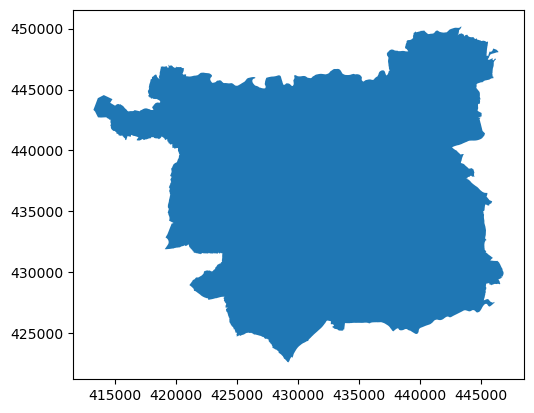

In [134]:
#Keep only chosen LA and plot it
chosen_LA = LAD_2024[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME]
chosen_LA.plot()

In [135]:
#Check CRS
print(chosen_LA.crs)

EPSG:27700


In [136]:
#Create outline of chosen LA
chosen_LA['outline'] = 1
LA_outline = chosen_LA.dissolve(by= 'outline')

c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


A function is created to subset datasets to the chosen local authority boundaries.

In [137]:
#Create function to subset data to the chosen LA
def subset_to_LAD(LAD_gdf, LAD_column_name, LAD_name, data_to_subset):
    """
    Subset a greenspace (or similar file) to only include greenspaces 
    within a chosen local authority.
    
    Parameters
    ----------
    LAD_gdf : geopandas.GeoDataFrame
        GeoDataFrame containing local authority district boundaries
    LAD_column_name : str
        Name of the column containing LAD names
    LAD_name : str
        Name of the specific LAD to subset to
    data_to_subset : geopandas.GeoDataFrame
        Data to be subset to the chosen LAD
        
    Returns
    -------
    geopandas.GeoDataFrame
        Data subset to only include features within the chosen LAD
    """
    chosen_LAD = LAD_gdf.loc[LAD_gdf[LAD_column_name] == LAD_name, :]
    chosen_LAD = chosen_LAD.to_crs(data_to_subset.crs)
    data_subset_to_LAD = data_to_subset[data_to_subset.within(chosen_LAD.union_all())]
    return data_subset_to_LAD

## 2- Combining OS and OSM data

This section combines OS and OSM datasets to identify existing Community Growing Schemes in Leeds. Greenspaces marked as private are excluded.

### A- Ordnance Survey (OS) Green Spaces

The Green Spaces data is downloaded from [Ordnance Survey](https://osdatahub.os.uk/data/downloads/open/OpenGreenspace).
The OS green spaces data is then subsetted to include only green spaces within the chosen local authority (here Leeds). It is then subsetted again to only include spaces that are considered to be existing CGSs.

Information about definitions of the OS green spaces functions can be found [here](https://docs.os.uk/os-downloads/products/land-and-terrain-portfolio/os-open-greenspace/os-open-greenspace-technical-specification/code-lists/functionvalue).

In [138]:
# Define path to OS green spaces data
OPGS_PATH = f"{DATA_DIR}\OS_Greenspace_UK\Data\opgrsp_gb.gpkg"

In [139]:
# Check available layers in the OS Open Greenspace file
print("Available layers in OS Open Greenspace:")
layers = fiona.listlayers(OPGS_PATH)
for layer in layers:
    print(f"  - {layer}")

Available layers in OS Open Greenspace:
  - access_point
  - greenspace_site


In [140]:
# Load OS Open Greenspace data (this loads all the data - so would not recommend visualising at this stage)
print("\nLoading OS Open Greenspace data...")
os_greenspace_access = gpd.read_file(OPGS_PATH, layer='access_point')
os_greenspace_site = gpd.read_file(OPGS_PATH, layer='greenspace_site')

print(f"Loaded {len(os_greenspace_access)} access points")
print(f"Loaded {len(os_greenspace_site)} greenspace sites")


Loading OS Open Greenspace data...
Loaded 355705 access points
Loaded 165978 greenspace sites


In [141]:
# Subset OS greenspace data to the target LAD
print(f"\nSubsetting OS greenspace data to {LOCAL_AUTHORITY_NAME}...")

greenspace_sites_lad = subset_to_LAD(
    LAD_gdf=LAD_2024, 
    LAD_column_name='LAD24NM', 
    LAD_name=LOCAL_AUTHORITY_NAME, 
    data_to_subset=os_greenspace_site
)

greenspace_access_lad = subset_to_LAD(
    LAD_gdf=LAD_2024, 
    LAD_column_name='LAD24NM', 
    LAD_name=LOCAL_AUTHORITY_NAME, 
    data_to_subset=os_greenspace_access
)

print(f"OS greenspace sites in {LOCAL_AUTHORITY_NAME}: {len(greenspace_sites_lad)}")
print(f"OS greenspace access points in {LOCAL_AUTHORITY_NAME}: {len(greenspace_access_lad)}")

# Display sample data
print("\nSample OS greenspace data:")
print(greenspace_sites_lad[['id', 'distinctive_name_1', 'function']].head())


Subsetting OS greenspace data to Leeds...
OS greenspace sites in Leeds: 1493
OS greenspace access points in Leeds: 3636

Sample OS greenspace data:
                                       id                 distinctive_name_1  \
3    49E9C763-2EBD-A491-E063-8CCAA00A0EF3                               None   
50   49E9C762-B904-A491-E063-8CCAA00A0EF3                               None   
59   49E9C762-5AEF-A491-E063-8CCAA00A0EF3  Holy Family Roman Catholic Church   
147  49E9C762-55E5-A491-E063-8CCAA00A0EF3                               None   
193  49E9C6EE-2D3A-A491-E063-8CCAA00A0EF3                           Low Moor   

                  function  
3             Tennis Court  
50   Other Sports Facility  
59       Religious Grounds  
147          Bowling Green  
193  Public Park Or Garden  


In [142]:
print('Total OS greenspaces in', LOCAL_AUTHORITY_NAME,':', greenspace_sites_lad['id'].nunique())

Total OS greenspaces in Leeds : 1493


In [143]:
# Greenspace in LA by type
greenspace_sites_lad['function'].value_counts()

function
Playing Field                             266
Play Space                                249
Public Park Or Garden                     227
Religious Grounds                         175
Other Sports Facility                     168
Allotments Or Community Growing Spaces    165
Bowling Green                              88
Tennis Court                               79
Cemetery                                   51
Golf Course                                25
Name: count, dtype: int64

In [144]:
#Check CRS
print(greenspace_sites_lad.crs)

EPSG:27700


In [145]:
greenspace_sites_lad.head()

,id,function,distinctive_name_1,distinctive_name_2,distinctive_name_3,distinctive_name_4,geometry
3,49E9C763-2EBD-A491-E063-8CCAA00A0EF3,Tennis Court,None,None,None,None,"MULTIPOLYGON (((442188.77 430186.17, 442193.13..."
50,49E9C762-B904-A491-E063-8CCAA00A0EF3,Other Sports Facility,None,None,None,None,"MULTIPOLYGON (((435216.09 432431.7, 435234.94 ..."
59,49E9C762-5AEF-A491-E063-8CCAA00A0EF3,Religious Grounds,Holy Family Roman Catholic Church,None,None,None,"MULTIPOLYGON (((428100.57 432878.55, 428129.35..."
147,49E9C762-55E5-A491-E063-8CCAA00A0EF3,Bowling Green,None,None,None,None,"MULTIPOLYGON (((427259.46 433695.76, 427231.4 ..."
193,49E9C6EE-2D3A-A491-E063-8CCAA00A0EF3,Public Park Or Garden,Low Moor,None,None,None,"MULTIPOLYGON (((427857.67 433653.59, 427826.02..."


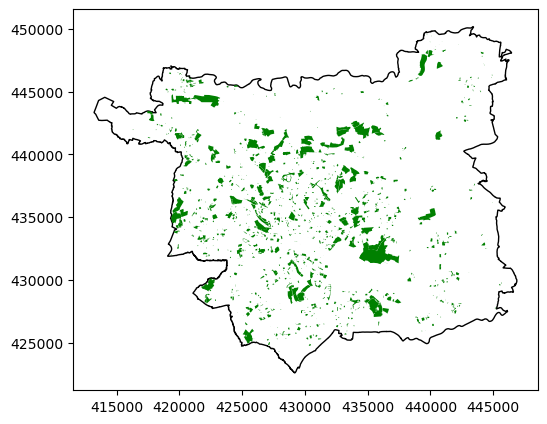

In [146]:
#Plot OS Greenspaces in Local Authority
fig , ax = plt.subplots(figsize=(6, 6))

#Plot outline first
LA_outline.plot(
    ax= ax,
    facecolor= 'none',
    edgecolor='black',
    linewidth=1
)

#Plot greenspaces
greenspace_sites_lad.plot(
    ax=ax,
    color='green'
)

plt.show()

In this section, only the OS green spaces with existing Community Growing Schemes are kept.

OS defines the 'Allotments Or Community Growing Spaces' function as: "Areas of land for growing fruit, vegetables and other plants, either in individual allotments or as a community activity. Produce is for the grower's own consumption and not primarily for commercial activity."

In [147]:
os_existing_cgs = greenspace_sites_lad[greenspace_sites_lad['function'] == 'Allotments Or Community Growing Spaces']

### B- OpenStreetMap API data

The existing CGSs data is collected from the [OpenStreetMap API](https://www.openstreetmap.org).
The map features, corresponding to existing CGSs are selected from [here](https://wiki.openstreetmap.org/wiki/Map_features).
The data is then subsetted to the chosen local authority (here Leeds).

This article is also useful: https://pythongis.org/part2/chapter-09/nb/00-retrieving-osm-data.html 

OSM Key| Value| Description
-------|----|-------
garden:type|community|Located in parks or other public spaces, community gardens are operated by an informal group of local residents. To some, community gardening is a leisurely social activity. To others, it is a response to concerns about food security.
garden:style|herb_garden|A garden used to grow herbs (spices and medical plants).
landuse|allotments|Allotment gardens (known as community gardens in the United States) are characterised by a concentration in one place of a few or up to several hundreds of land parcels that are assigned to individuals or families. In allotment gardens, the parcels are cultivated individually, contrary to community gardens where the entire area is tended collectively by a group of people
~~landuse~~|~~greenhouse_horticulture~~|~~The area of land used for growing plants in greenhouses. Buildings, water reservoirs and open areas around greenhouses used for operating the greenhouses should be considered part of such landuse.~~
landuse|orchard| Intentional planting of trees or shrubs maintained for food production, including orchards and similar plantations. Orchards usually comprise fruit or nut-producing trees grown for commercial production.
~~landuse~~|~~plant_nursery~~|~~Plant nursery grows plants (often for sale), much like a farm grows crops for food. Unlike a farm, a plant nursery generally relocates the whole of the plants they grow, as living plants, rather than only selling produce produced from them. Plants being grown can include any type of plant, from flowers to trees, including Christmas trees.~~

In [148]:
# Define OSM tags for existing CGSs

osm_tags = {
    'garden:type': ['community',
                    'herb_garden'],
    'landuse': ['allotments', 
                'orchard'
                ]
}

print("Extracting OSM CGS data...")
print(f"Tags to extract: {osm_tags}")

# Get the target LAD geometry
target_lad_geom = LAD_2024.loc[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME, :]

try:
    # Extract OSM features
    gdf = ox.features_from_polygon(
        target_lad_geom.to_crs("EPSG:4326").union_all(), 
        osm_tags
    )
    
    filters = [gdf[tag_key].isin(tag_values) 
           for tag_key, tag_values in osm_tags.items() 
           if tag_key in gdf.columns]

    osm_cgs = gdf[pd.concat(filters, axis=1).any(axis=1)].reset_index() if filters else gpd.GeoDataFrame()
    
    print(f"Extracted {len(osm_cgs)} OSM CGSs features in {LOCAL_AUTHORITY_NAME}")
    
    # Display sample data
    print("\nSample OSM CGS data:")
    available_cols = [col for col in ['name', 'leisure', 'garden:type', 'landuse', 'man_made'] if col in osm_cgs.columns]
    print(osm_cgs[available_cols].head())
    
except Exception as e:
    print(f"Error extracting OSM data: {e}")
    osm_cgs = gpd.GeoDataFrame()

Extracting OSM CGS data...
Tags to extract: {'garden:type': ['community', 'herb_garden'], 'landuse': ['allotments', 'orchard']}
Extracted 261 OSM CGSs features in Leeds

Sample OSM CGS data:
                               name leisure garden:type landuse
0      Headingley Community Orchard  garden   community     NaN
1     Wigton Moor Community Orchard  garden   community     NaN
2  Maid Marian Orchard, Copley Lane  garden   community     NaN
3                 Ouzlewell Orchard  garden   community     NaN
4      Spring Lane Sidings, Orchard  garden   community     NaN


In [149]:
osm_cgs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   element           261 non-null    object  
 1   id                261 non-null    int64   
 2   geometry          261 non-null    geometry
 3   garden:type       79 non-null     object  
 4   leisure           79 non-null     object  
 5   name              189 non-null    object  
 6   website           13 non-null     object  
 7   operator          18 non-null     object  
 8   operator:type     5 non-null      object  
 9   description       23 non-null     object  
 10  access            10 non-null     object  
 11  email             2 non-null      object  
 12  fee               5 non-null      object  
 13  note              9 non-null      object  
 14  landuse           184 non-null    object  
 15  ref:GB:uprn       28 non-null     object  
 16  source            

### C- Combining OSM and OS data

Cleaning and data prep.

In [150]:
# Tidy OS names 
os_existing_cgs['Other name(s) (OS)']= os_existing_cgs[['distinctive_name_2','distinctive_name_3','distinctive_name_4']].apply(lambda x: ', '.join(x[x.notnull()]), axis = 1).replace(r'^\s*$', np.nan, regex=True)
os_existing_cgs['Other name(s) (OS)'].unique()

C:\Users\qxnq723\AppData\Local\Temp\ipykernel_33088\3136628130.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  os_existing_cgs['Other name(s) (OS)']= os_existing_cgs[['distinctive_name_2','distinctive_name_3','distinctive_name_4']].apply(lambda x: ', '.join(x[x.notnull()]), axis = 1).replace(r'^\s*$', np.nan, regex=True)
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


array([nan])

In [151]:
osm_cgs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   element           261 non-null    object  
 1   id                261 non-null    int64   
 2   geometry          261 non-null    geometry
 3   garden:type       79 non-null     object  
 4   leisure           79 non-null     object  
 5   name              189 non-null    object  
 6   website           13 non-null     object  
 7   operator          18 non-null     object  
 8   operator:type     5 non-null      object  
 9   description       23 non-null     object  
 10  access            10 non-null     object  
 11  email             2 non-null      object  
 12  fee               5 non-null      object  
 13  note              9 non-null      object  
 14  landuse           184 non-null    object  
 15  ref:GB:uprn       28 non-null     object  
 16  source            

In [152]:
# Clean osm data to remove green spaces/CGSs marked as private
osm_cgs = osm_cgs.loc[osm_cgs['access']!='private',:]


# Define OS 'function' equivalent for OSM data
osm_cgs['Type (OSM)'] = osm_cgs[['garden:type', 'landuse']].apply(
        lambda x: ', '.join(sorted(x.dropna().astype(str))), axis=1
    )

osm_cgs['Type (OSM)'].value_counts()

Type (OSM)
allotments            170
community              76
orchard                10
community, orchard      2
Name: count, dtype: int64

Combine data

In [153]:
# Combine OS and OSM data into one df

if len(osm_cgs) > 0:
    # Prepare OS CGS data for joining
    os_gs_to_join = os_existing_cgs[['distinctive_name_1', 'Other name(s) (OS)','function', 'id', 'geometry']].copy()
    os_gs_to_join['flag_OS'] ='OS'
    os_gs_to_join.columns = ['Name (OS)', 'Other name(s) (OS)','Type (OS)', 'OS ID', 'geometry','flag_OS']
    
    # Prepare OSM CGS data for joining
    # Combine OSM tags into one value
    osm_cgs['Type (OSM)'] = osm_cgs[['garden:type', 'landuse']].apply(
        lambda x: ', '.join(sorted(x.dropna().astype(str))), axis=1
    )

    # Select relevant columns for OSM data
    
    osm_cols = ['name', 'alt_name','Type (OSM)', 'osmid', 'geometry','flag_OSM']
    available_osm_cols = [col for col in osm_cols if col in osm_cgs.columns]
    osm_gs_to_join = osm_cgs[available_osm_cols].copy()
    osm_gs_to_join['flag_OSM'] ='OSM'
    # Ensure we have the right column names
    if 'name' in osm_gs_to_join.columns:
        osm_gs_to_join = osm_gs_to_join.rename(columns={'name': 'Name (OSM)'})
    else:
        osm_gs_to_join['Name (OSM)'] = None
        
    if 'osmid' in osm_gs_to_join.columns:
        osm_gs_to_join = osm_gs_to_join.rename(columns={'osmid': 'OSM ID'})
    else:
        osm_gs_to_join['OSM ID'] = None
    
    if 'alt_name' in osm_gs_to_join.columns:
        osm_gs_to_join = osm_gs_to_join.rename(columns={'alt_name': 'Other name(s) (OSM)'})
    else:
        osm_gs_to_join['Other name(s) (OSM)'] = None
    # Ensure both datasets have the same CRS
    osm_gs_to_join = osm_gs_to_join.to_crs(os_gs_to_join.crs)

    # Combine OS and OSM data
    print("Combining OS and OSM CGS data...")
    combined_existing_cgs = pd.concat([os_gs_to_join, osm_gs_to_join], ignore_index=True)
    
    # Create a unified flag for the data origin and remove temp flag columns 
    combined_existing_cgs['flag']= combined_existing_cgs['flag_OS'].fillna(combined_existing_cgs['flag_OSM'])
    combined_existing_cgs =combined_existing_cgs.drop(columns={'flag_OS','flag_OSM'})
    
    print(f"Combined dataset: {len(combined_existing_cgs)} features")
    print(f"  - OS features: {len(os_gs_to_join)}")
    print(f"  - OSM features: {len(osm_gs_to_join)}")
    
else:
    print("No OSM data available, using only OS data")
    combined_existing_cgs = os_gs_to_join.copy()

Combining OS and OSM CGS data...
Combined dataset: 423 features
  - OS features: 165
  - OSM features: 258


## 3- Adding Allotment data - Leeds City Council

The polygons of allotments in Leeds are scraped from the Leeds Council ArcGis webpage.

### A- Web scraping

In [154]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [155]:
url= "https://services1.arcgis.com/brSffcdOV7o1pDVT/arcgis/rest/services/Allotments/FeatureServer/1/query"
base_url = "https://services1.arcgis.com/brSffcdOV7o1pDVT/arcgis/rest/services/Allotments/FeatureServer/1"

#Get meta data
meta= requests.get(base_url, params={'f': 'json'}).json()
print(meta.keys())

headers= {
    'User-Agent': 'Mozilla/5.0',
    'Referer': 'https://www.argis.com'
}

#List to store feature rows
all_rows= []
#Control pagination
offset= 0
batch_size= 2000

#Loop through all data
while True:
    params = {
    'where': '1=1', #get everything
    'outFields': '*', #return all columns
    'returnGeometry': 'true', #include spatial data (polygons)
    'f': 'json', #response format
    'resultOffset': offset,
    'resultRecordCount': batch_size
    }

    #Send request
    data = requests.get(url, params= params, headers= headers).json()

    #Get list of features
    features = data.get('features', [])
    if not features:
        break
    
    #Loop through features
    for f in features:
        row= f['attributes']
        geom = f.get('geometry')
    
        #Polygons
        if geom and 'rings' in geom:
            row['geometry_type'] = 'polygon'
            row['geometry']= shape({'type': 'Polygon', 'coordinates': geom['rings']}) #store polygon geometry
        #Polyline
        elif geom and 'paths' in geom:
            row['geometry_type'] = 'polyline'
            row['geometry']= shape({'type': 'LineString', 'coordinates': geom['paths'][0]}) #store line geometry
        #Points
        elif 'Lat' in row and 'Lon' in row:
            row['geometry_type'] = 'point'
            row['geometry'] = Point(row['Lon'], row['Lat'])
        #Fallback
        else:
            row['geometry_type'] = 'unknown'
            row['geometry'] = None
        #Store results
        all_rows.append(row)

    offset += batch_size #move to next batch
    print(f'Fetched {offset} records')

#Convert to GeoDataFrame
df = pd.DataFrame(all_rows)
LeedsCouncil_allotments = gpd.GeoDataFrame(df, geometry='geometry', crs= 'EPSG:27700')

print('Done:', len(LeedsCouncil_allotments), 'allotments in Leeds')

dict_keys(['currentVersion', 'id', 'name', 'type', 'serviceItemId', 'cacheMaxAge', 'displayField', 'description', 'copyrightText', 'defaultVisibility', 'editingInfo', 'relationships', 'isDataVersioned', 'hasContingentValuesDefinition', 'supportsAppend', 'supportsCalculate', 'supportsASyncCalculate', 'supportsTruncate', 'supportsAttachmentsByUploadId', 'supportsAttachmentsResizing', 'supportsRollbackOnFailureParameter', 'supportsStatistics', 'supportsExceedsLimitStatistics', 'supportsAdvancedQueries', 'supportsValidateSql', 'supportsCoordinatesQuantization', 'supportsLayerOverrides', 'supportsTilesAndBasicQueriesMode', 'supportsFieldDescriptionProperty', 'supportsQuantizationEditMode', 'supportsColumnStoreIndex', 'supportsApplyEditsWithGlobalIds', 'supportsMultiScaleGeometry', 'supportsReturningQueryGeometry', 'enableNullGeometry', 'hasGeometryProperties', 'geometryProperties', 'advancedQueryCapabilities', 'advancedQueryAnalyticCapabilities', 'queryBinsCapabilities', 'supportedOperation

In [156]:
#Check
LeedsCouncil_allotments.info()
print(LeedsCouncil_allotments.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   OBJECTID        133 non-null    int64   
 1   SITEREF         133 non-null    object  
 2   BOUNDNUM        133 non-null    object  
 3   SITEALIAS       133 non-null    object  
 4   SITESORT        133 non-null    int64   
 5   SITEADDRESS     133 non-null    object  
 6   SITEPLAN        133 non-null    object  
 7   TYPOLOGYTXT     133 non-null    object  
 8   SITEPLANPOLICY  133 non-null    object  
 9   HMCAREA         133 non-null    object  
 10  AREAHA          133 non-null    float64 
 11  PLANREFLABEL    133 non-null    object  
 12  WARD_NAME       133 non-null    object  
 13  Demand          130 non-null    float64 
 14  AG3Score        130 non-null    float64 
 15  Shape__Area     133 non-null    float64 
 16  Shape__Length   133 non-null    float64 
 17  geometry

In [157]:
LeedsCouncil_allotments.head()

,OBJECTID,SITEREF,BOUNDNUM,SITEALIAS,SITESORT,SITEADDRESS,SITEPLAN,TYPOLOGYTXT,SITEPLANPOLICY,HMCAREA,AREAHA,PLANREFLABEL,WARD_NAME,Demand,AG3Score,Shape__Area,Shape__Length,geometry_type,geometry
0,1,GRN01786,GRN017861,G1905,41905,Lydgate Place Allotments,SAP,Allotments,Policy GS1,Outer West,0.32,G1905,Calverley & Farsley,2105.348072,0.633308,3202.612701,380.540071,polygon,"POLYGON ((420311.35 437303, 420311.35 437298.6..."
1,2,GRN01590,GRN015901,G1702,41702,Pondfields Drive (East View) Allotments,SAP,Allotments,Policy GS1,Outer South East,0.92,G1702,Kippax & Methley,3934.825605,0.974207,9265.964157,428.409451,polygon,"POLYGON ((441766.9 430560.3, 441767.1 430560.2..."
2,3,GRN00122,GRN001221,G125,40125,Shafton Lane Allotments,SAP,Allotments,Policy GS1,Inner Area,1.58,G125,Beeston & Holbeck,1680.194990,3.918196,15878.601120,680.689518,polygon,"POLYGON ((428754.378 432144.598, 428618.9 4321..."
3,4,GRN01253,GRN012531,G1349,41349,Calverley Allotments,SAP,Allotments,Policy GS1,Outer West,0.50,G1349,Calverley & Farsley,2123.417028,0.981123,5031.726547,410.203203,polygon,"POLYGON ((420703.8 437200.4, 420703.3 437195.6..."
4,5,GRN01410,GRN014101,G1516,41516,Gallows Hill Allotments,SAP,Allotments,Policy GS1,Outer North West,0.22,G1516,Otley & Yeadon,1984.513056,0.461910,2206.221878,199.641861,polygon,"POLYGON ((421097.9 445873.8, 421100.7 445869.3..."


In [158]:
print(LeedsCouncil_allotments.is_valid.value_counts())
#Fix any invalid geometries
LeedsCouncil_allotments['geometry'] = LeedsCouncil_allotments.buffer(0)
print(LeedsCouncil_allotments.is_valid.value_counts())

True     129
False      4
Name: count, dtype: int64
True    133
Name: count, dtype: int64


The information about allotment contacts are also scraped from the Leeds Council ArcGis webpage

In [159]:
url= "https://services1.arcgis.com/brSffcdOV7o1pDVT/ArcGIS/rest/services/Allotments_contacts/FeatureServer/0/query"
base_url = "https://services1.arcgis.com/brSffcdOV7o1pDVT/ArcGIS/rest/services/Allotments_contacts/FeatureServer/0"

#Get meta data
meta= requests.get(base_url, params={'f': 'json'}).json()
print(meta.keys())


headers= {
    'User-Agent': 'Mozilla/5.0',
    'Referer': 'https://www.argis.com'
}

#Get meta data
meta= requests.get(url, params={'f': 'json'}).json()
print(meta.keys())

#List to store feature rows
all_rows= []
#Control pagination
offset= 0
batch_size= 2000

#Loop through all data
while True:
    params = {
    'where': '1=1', #get everything
    'outFields': '*', #return all columns
    'returnGeometry': 'true', #include spatial data (polygons)
    'f': 'json', #response format
    'resultOffset': offset,
    'resultRecordCount': batch_size
    }

    #Send request
    data = requests.get(url, params= params, headers= headers).json()

    #Get list of features
    features = data.get('features', [])
    if not features:
        break
    
    #Loop through features
    for f in features:
        row= f['attributes']
        geom = f.get('geometry')
    
        #Polygons
        if geom and 'rings' in geom:
            row['geometry_type'] = 'polygon'
            row['geometry']= shape({'type': 'Polygon', 'coordinates': geom['rings']}) #store polygon geometry
        #Polyline
        elif geom and 'paths' in geom:
            row['geometry_type'] = 'polyline'
            row['geometry']= shape({'type': 'LineString', 'coordinates': geom['paths'][0]}) #store line geometry
        #Points
        elif 'Lat' in row and 'Lon' in row:
            row['geometry_type'] = 'point'
            row['geometry'] = Point(row['Lon'], row['Lat'])
        #Fallback
        else:
            row['geometry_type'] = 'unknown'
            row['geometry'] = None
        #Store results
        all_rows.append(row)

    offset += batch_size #move to next batch
    print(f'Fetched {offset} records')

#Convert to GeoDataFrame
df = pd.DataFrame(all_rows)
allotments_contacts = gpd.GeoDataFrame(df, geometry='geometry', crs= 'EPSG:4326')
allotments_contacts = allotments_contacts.to_crs('EPSG:27700')

print('Done:', len(allotments_contacts), 'rows exported')

dict_keys(['currentVersion', 'id', 'name', 'type', 'serviceItemId', 'cacheMaxAge', 'displayField', 'description', 'copyrightText', 'defaultVisibility', 'editingInfo', 'relationships', 'isDataVersioned', 'hasContingentValuesDefinition', 'supportsAppend', 'supportsCalculate', 'supportsASyncCalculate', 'supportsTruncate', 'supportsAttachmentsByUploadId', 'supportsAttachmentsResizing', 'supportsRollbackOnFailureParameter', 'supportsStatistics', 'supportsExceedsLimitStatistics', 'supportsAdvancedQueries', 'supportsValidateSql', 'supportsCoordinatesQuantization', 'supportsLayerOverrides', 'supportsTilesAndBasicQueriesMode', 'supportsFieldDescriptionProperty', 'supportsQuantizationEditMode', 'supportsColumnStoreIndex', 'supportsApplyEditsWithGlobalIds', 'supportsReturningQueryGeometry', 'enableNullGeometry', 'advancedQueryCapabilities', 'advancedQueryAnalyticCapabilities', 'queryBinsCapabilities', 'supportedOperationsWithCollation', 'advancedEditingCapabilities', 'infoInEstimates', 'useStanda

In [160]:
#Load data
allotments_contacts.info()
print(allotments_contacts.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   FID            101 non-null    int64   
 1   Site_name      101 non-null    object  
 2   Postcode       101 non-null    object  
 3   Council_co     101 non-null    object  
 4   Contact_de     101 non-null    object  
 5   Lat            101 non-null    float64 
 6   Lon            101 non-null    float64 
 7   BNG_x          101 non-null    float64 
 8   BNG_y          101 non-null    float64 
 9   geometry_type  101 non-null    object  
 10  geometry       101 non-null    geometry
dtypes: float64(4), geometry(1), int64(1), object(5)
memory usage: 8.8+ KB
EPSG:27700


In [161]:
allotments_contacts.head()

,FID,Site_name,Postcode,Council_co,Contact_de,Lat,Lon,BNG_x,BNG_y,geometry_type,geometry
0,1,Shafton Lane,LS10,Allotment association,mailto:neilcrozier1@gmail.com,53.785638,-1.566593,428653.9935,432231.4731,point,POINT (428653.708 432233.239)
1,2,Whitehouse Farm,LS10,Allotment association,mailto:allotments@leeds.gov.uk,53.768740,-1.527512,431241.4312,430367.8091,point,POINT (431241.145 430369.607)
2,3,Old Lane,LS11,Allotment association,mailto:oldlanelotts@gmail.com,53.771632,-1.566968,428638.7744,430673.0339,point,POINT (428638.495 430674.799)
3,4,Parkside Beeston,LS11,Allotment association,mailto:allotments@leeds.gov.uk,53.764568,-1.554212,429484.4391,429892.2868,point,POINT (429484.162 429894.068)
4,5,Clarkesfield,LS11,Allotment association,mailto:allotments@leeds.gov.uk,53.769477,-1.551131,429684.0971,430439.7324,point,POINT (429683.813 430441.513)


In [162]:
#Check if geometries are valid
print(allotments_contacts.is_valid.value_counts())

True    101
Name: count, dtype: int64


The allotment information is added to Leeds Council allotment polygons.

In [163]:
# Match points within allotment polygons
matches = gpd.sjoin(allotments_contacts,
                  LeedsCouncil_allotments,
                  how= 'left',
                  predicate= 'within')

# Handle unmatched points
unmatched = matches[matches['index_right'].isna()].copy()

#Find nearest polygon within 50m distance
nearest = gpd.sjoin_nearest(
    unmatched.drop(columns=['index_right']),
    LeedsCouncil_allotments,
    how='left',
    max_distance= 50,
    distance_col= 'distance'
)

#Keep sucessful direct matches
matched = matches[matches['index_right'].notna()]

#Combine the matches (inside or near allotment polygons)
all_matches = pd.concat([matched, nearest], ignore_index=True)
print(len(all_matches), 'allotment info matched')

#Attach the contact info back to their associated allotment polygons

#Keep contact info
contact_cols = ['Contact_de', 'Council_co', 'index_right']
contact_info = all_matches[contact_cols]
#Avoid duplicates
contact_info = contact_info.sort_values('index_right').drop_duplicates(subset='index_right')

LC_allotments = LeedsCouncil_allotments.merge(
    contact_info,
    left_index= True,
    right_on='index_right',
    how='left'
)

#check
print(len(LC_allotments), 'Leeds City Council allotments')

101 allotment info matched
133 Leeds City Council allotments


### B- Combining CGSs (OS + OSM) data with Leeds City Council Allotments data

In [164]:
# Combine Leeds Council allotemnts with OS and OSM data into one df

if len(LC_allotments) > 0:
    # Prepare LCC data for joining
    lc_allot_to_join = LC_allotments[['SITEREF', 'SITEADDRESS',  'TYPOLOGYTXT', 'Council_co', 'Contact_de', 'geometry']].copy()
    lc_allot_to_join['flag_LCC'] = 'LCC'
    lc_allot_to_join.columns = ['SITEREF', 'SITEADDRESS',  'TYPOLOGYTXT', 'Council_co', 'Contact_de', 'geometry', 'flag_LCC']

    # Rename columns
    lc_allot_to_join = lc_allot_to_join.rename(columns={'SITEADDRESS': 'Name (LCC)'})
    lc_allot_to_join = lc_allot_to_join.rename(columns={'TYPOLOGYTXT': 'Type (LCC)'})
    lc_allot_to_join = lc_allot_to_join.rename(columns={'SITEREF': 'LCC ID'})
    lc_allot_to_join = lc_allot_to_join.rename(columns={'Council_co': 'Management (LCC)'})
    lc_allot_to_join = lc_allot_to_join.rename(columns={'Contact_de': 'Email (LCC)'})
    #Reorder columns
    lc_allot_to_join= lc_allot_to_join[['Name (LCC)', 'Type (LCC)', 'LCC ID', 'Management (LCC)', 'Email (LCC)', 'geometry', 'flag_LCC']]

    # Ensure both datasets have the same CRS
    lc_allot_to_join= lc_allot_to_join.to_crs(combined_existing_cgs.crs)

    # Combine OS+OSM data with LCC data
    print("Combining CGS data (OS and OSM) with Leeds City Council allotments...")
    combined_exist_cgs = pd.concat([lc_allot_to_join, combined_existing_cgs], ignore_index=True)
    
    # Create a unified flag for the data origin and remove temp flag columns 
    combined_exist_cgs['flag_bis']= combined_exist_cgs['flag'].fillna(combined_exist_cgs['flag_LCC'])
    combined_exist_cgs = combined_exist_cgs.drop(columns={'flag','flag_LCC'})
    combined_exist_cgs = combined_exist_cgs.rename(columns={'flag_bis': 'flag'})
    
    print(f"Combined dataset: {len(combined_exist_cgs)} features")
    print(f"  - LCC features: {len(lc_allot_to_join)}")
    
else:
    print("No LCC data available, using only OS ans OSM data")
    combined_exist_cgs = combined_existing_cgs.copy()

Combining CGS data (OS and OSM) with Leeds City Council allotments...
Combined dataset: 556 features
  - LCC features: 133


In [165]:
combined_exist_cgs.head()

,Name (LCC),Type (LCC),LCC ID,Management (LCC),Email (LCC),geometry,Name (OS),Other name(s) (OS),Type (OS),OS ID,Name (OSM),Other name(s) (OSM),Type (OSM),OSM ID,flag
0,Lydgate Place Allotments,Allotments,GRN01786,NaN,NaN,"POLYGON ((420311.35 437303, 420311.35 437298.6...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LCC
1,Pondfields Drive (East View) Allotments,Allotments,GRN01590,NaN,NaN,"POLYGON ((441766.9 430560.3, 441767.1 430560.2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LCC
2,Shafton Lane Allotments,Allotments,GRN00122,Allotment association,mailto:neilcrozier1@gmail.com,"POLYGON ((428754.378 432144.598, 428618.9 4321...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LCC
3,Calverley Allotments,Allotments,GRN01253,NaN,NaN,"POLYGON ((420703.8 437200.4, 420703.3 437195.6...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LCC
4,Gallows Hill Allotments,Allotments,GRN01410,NaN,NaN,"POLYGON ((421097.9 445873.8, 421100.7 445869.3...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LCC


In [166]:
# Note lots of overlapping between the three datasets / diagreement on boundaries 
combined_exist_cgs.explore('flag', tooltip=['Type (OS)','Type (OSM)', 'Type (LCC)'], alpha=0.5)

The OS data seem to be in general the largest polygons, thus in the case of geometries overlapping, the OS geometry must be kept in priority (while keeping OSM/LCC information if there is any).

### C- Avoiding duplicates/ geometries overlapping

Some CGSs have overlapping geometries between OS, OSM and LCC. To avoid duplicates in the CGSs data, overlapping polygons are combined to only show the OS geometry (or OSM as fallback).

In [167]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [168]:
#Find overlapping geometries between OS, OSM and LCC
#Create spatial connectivity graph

#Create spatial index
sindex = combined_exist_cgs.sindex

#Create empty network graph
# each polygon = a node
# overlaps/intersections = edges
G = nx.Graph()

#Add all rows as nodes
G.add_nodes_from(combined_exist_cgs.index)

#Find intersecting polygons
#Loop through each polygon in dataset
for idx, geom in combined_exist_cgs.geometry.items():
    #Find potential matches using spatial index = find polygons near in bounding box
    #this avoids checking against all polygons (time and energy consuming)
    potential = list(sindex.intersection(geom.bounds))
    #Now find if nearby polygons are intersecting or not
    matches = combined_exist_cgs.iloc[potential]
    matches= matches[matches.geometry.intersects(geom)]
    
    #Loop though all polygons truly intersecting current polygon
    for match_idx in matches.index:
        #Avoid self intersection
        if idx != match_idx:
            #Create connection between intersecting polygons
            G.add_edge(idx, match_idx)

In [169]:
#Create clusters
# by finding connected groups of nodes in graph G

clusters = list(nx.connected_components(G))

#Store row index and cluster id
cluster_map= {}

#Assign cluster ID to each polygon
for cluster_id, component in enumerate(clusters):
    for idx in component:
        cluster_map[idx] = cluster_id

combined_exist_cgs['cluster'] = combined_exist_cgs.index.map(cluster_map)

In [170]:
#Spatially match the allotments between OS, OSM and LCC
#By grouping rows by cluster (previously created)

#Create merge flags function (provenance tracking)
def merge_flags(series):
    return '_'.join(sorted(set(series.dropna())))

#---------------------------------------------------------------

#Group by cluster and aggregate their attributes (no geometry here)
agg = combined_exist_cgs.groupby('cluster').agg({
    'Name (LCC)': 'first',
    'Type (LCC)': 'first',
    'LCC ID': 'first',
    'Management (LCC)': 'first',
    'Email (LCC)': 'first',
    
    'Name (OS)': 'first',
    'Other name(s) (OS)': 'first',
    'Type (OS)': 'first',
    'OS ID': 'first',
    
    'Name (OSM)': 'first',	
    'Other name(s) (OSM)': 'first',
    'Type (OSM)': 'first',
    'OSM ID': 'first',
    
    'flag': merge_flags, 
}).reset_index()

In [171]:
#Create geometry selection function
# OS geometry takes priority
# if OS not present, OSM takes priority

def pick_geometry(group):
    
    flags= merge_flags(group['flag'])
    
    #1- OS always takes priority
    if 'OS' in flags.split('_'):
        os_rows = group[group['flag'] == 'OS']
        if len(os_rows) > 0:
            return os_rows.iloc[0].geometry
    
    #2- OSM fallback
    if 'OSM' in flags.split('_'):
        osm_rows = group[group['flag'] == 'OSM']
        if len(osm_rows) > 0:
            return osm_rows.iloc[0].geometry
    
    #Final fallback
    return group.iloc[0].geometry

#----------------------------------------------------------------

#Apply the geometry selection per cluster
geom = (combined_exist_cgs
        .groupby('cluster')
        .apply(pick_geometry)
        .reset_index())

#Retain only cluster ID and geometries
geom.columns= ['cluster', 'geometry']

#--------------------------------------------------------------

#Merge attributes and geometry based on clusters
final = agg.merge(geom, on='cluster')

final_exist_CGS = gpd.GeoDataFrame(
    final, 
    geometry='geometry', 
    crs= combined_exist_cgs.crs)

#Check
final_exist_CGS.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   cluster              264 non-null    int64   
 1   Name (LCC)           126 non-null    object  
 2   Type (LCC)           126 non-null    object  
 3   LCC ID               126 non-null    object  
 4   Management (LCC)     80 non-null     object  
 5   Email (LCC)          80 non-null     object  
 6   Name (OS)            104 non-null    object  
 7   Other name(s) (OS)   0 non-null      float64 
 8   Type (OS)            156 non-null    object  
 9   OS ID                156 non-null    object  
 10  Name (OSM)           179 non-null    object  
 11  Other name(s) (OSM)  1 non-null      object  
 12  Type (OSM)           239 non-null    object  
 13  OSM ID               0 non-null      object  
 14  flag                 264 non-null    object  
 15  geometry       

C:\Users\qxnq723\AppData\Local\Temp\ipykernel_33088\4236348856.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pick_geometry)


In [172]:
final_exist_CGS['flag'].value_counts()

flag
LCC_OS_OSM    109
OSM            95
OS_OSM         33
LCC            11
OS             10
LCC_OS          4
LCC_OSM         2
Name: count, dtype: int64

So there were 109 CGSs in common between OS, OSM and LCC.

In [173]:
#Check rows where the same CGS was in OS, OSM and LCC
#Check information was retained in each column
triple_cgs = final_exist_CGS[final_exist_CGS['flag'] == 'LCC_OS_OSM']
triple_cgs.head()

,cluster,Name (LCC),Type (LCC),LCC ID,Management (LCC),Email (LCC),Name (OS),Other name(s) (OS),Type (OS),OS ID,Name (OSM),Other name(s) (OSM),Type (OSM),OSM ID,flag,geometry
1,1,Pondfields Drive (East View) Allotments,Allotments,GRN01590,None,None,Pondfields Drive Allotments,NaN,Allotments Or Community Growing Spaces,49E9C763-2C5C-A491-E063-8CCAA00A0EF3,None,None,allotments,None,LCC_OS_OSM,"MULTIPOLYGON (((441675.4 430602.7, 441689.1 43..."
2,2,Shafton Lane Allotments,Allotments,GRN00122,Allotment association,mailto:neilcrozier1@gmail.com,Shafton Lane Allotments,NaN,Allotments Or Community Growing Spaces,49E9C762-6CC0-A491-E063-8CCAA00A0EF3,Shafton Lane Allotments,None,allotments,None,LCC_OS_OSM,"MULTIPOLYGON (((428651.73 432238.5, 428597.35 ..."
4,4,Gallows Hill Allotments,Allotments,GRN01410,None,None,White Bridge Allotments,NaN,Allotments Or Community Growing Spaces,49E9C73B-2E4B-A491-E063-8CCAA00A0EF3,White Bridge Allotments,None,allotments,None,LCC_OS_OSM,"MULTIPOLYGON (((420859.32 446068.64, 420860.83..."
5,5,North Park Avenue Allotments,Allotments,GRN00473,Allotment association,mailto:allotments@leeds.gov.uk,North Park Avenue Allotments,NaN,Allotments Or Community Growing Spaces,49E9C761-F50E-A491-E063-8CCAA00A0EF3,Lidgett Lane Allotments,None,allotments,None,LCC_OS_OSM,"MULTIPOLYGON (((431555.32 438072.23, 431548.38..."
6,6,Beechwood Crescent Allotments,Allotments,GRN00139,None,None,None,NaN,Allotments Or Community Growing Spaces,49E9C762-2D69-A491-E063-8CCAA00A0EF3,Burley Model Allotments,None,allotments,None,LCC_OS_OSM,"MULTIPOLYGON (((427551.25 435404.14, 427579.5 ..."


In [174]:
triple_cgs['Type (OSM)'].value_counts()
#these triplets are either community growing spaces (2) or allotments (107)

Type (OSM)
allotments    107
community       2
Name: count, dtype: int64

In [175]:
final_exist_CGS['Type (OS)'].value_counts()
#OSM has 157 allotments
#OS has 156 allotments
#LCC has 126 allotments

Type (OS)
Allotments Or Community Growing Spaces    156
Name: count, dtype: int64

In [176]:
#Visualize the cleaned dataset of existing CGSs
#There shouldn't be any overlappin polygons now
final_exist_CGS.explore('flag', tooltip=['Type (OS)','Type (OSM)', 'Type (LCC)'], alpha=0.5)

## 4- Adding LGAP Data

### A-Web Scraping

The locations of [Leeds Green Activity Provider (LGAP)](https://lgap.co.uk/find-an-activity) are scraped from their [ArcGis Online feature layer](https://www.arcgis.com/apps/mapviewer/index.html?layers=6afec02763ab4f87887939ed4d073c70). Only the activities linked to gardening are kept.

In [177]:
url= "https://services1.arcgis.com/ENz4NUfCPx4lwh83/arcgis/rest/services/Green_activities_for_LGAP_map_view/FeatureServer/0/query"
base_url = "https://services1.arcgis.com/ENz4NUfCPx4lwh83/arcgis/rest/services/Green_activities_for_LGAP_map_view/FeatureServer/0"

#Get meta data
meta= requests.get(base_url, params={'f': 'json'}).json()
print(meta.keys())


headers= {
    'User-Agent': 'Mozilla/5.0',
    'Referer': 'https://www.argis.com'
}

#Get meta data
meta= requests.get(url, params={'f': 'json'}).json()
print(meta.keys())

#List to store feature rows
all_rows= []
#Control pagination
offset= 0
batch_size= 2000

#Loop through all data
while True:
    params = {
    'where': '1=1', #get everything
    'outFields': '*', #return all columns
    'returnGeometry': 'true', #include spatial data (polygons/points)
    'outSR': 4326,
    'f': 'json', #response format
    'resultOffset': offset,
    'resultRecordCount': batch_size
    }

    #Send request
    data = requests.get(url, params= params, headers= headers).json()

    #Get list of features
    features = data.get('features', [])
    if not features:
        break
    
    #Loop through features
    for f in features:
        row= f['attributes'].copy()
        geom = f.get('geometry')
    
        #Polygons
        if geom and 'rings' in geom:
            row['geometry_type'] = 'polygon'
            row['geometry']= shape({'type': 'Polygon', 'coordinates': geom['rings']}) #store polygon geometry
        #Polyline
        elif geom and 'paths' in geom:
            row['geometry_type'] = 'polyline'
            row['geometry']= shape({'type': 'LineString', 'coordinates': geom['paths'][0]}) #store line geometry
        #Points
        elif geom and 'x' in geom and 'y' in geom:
            row['geometry_type'] = 'point'
            row['geometry'] = Point(geom['x'], geom['y'])
        #Fallback
        else:
            row['geometry_type'] = 'unknown'
            row['geometry'] = None
        #Store results
        all_rows.append(row)

    offset += batch_size #move to next batch
    print(f'Fetched {offset} records')

#Convert to GeoDataFrame
df = pd.DataFrame(all_rows)
lgap = gpd.GeoDataFrame(df, geometry='geometry', crs= 'EPSG:4326')

#Convert crs
lgap = lgap.to_crs('EPSG:27700')

print('Done:', len(lgap), 'rows exported')

dict_keys(['currentVersion', 'id', 'name', 'type', 'serviceItemId', 'cacheMaxAge', 'isView', 'isUpdatableView', 'sourceSchemaChangesAllowed', 'displayField', 'description', 'copyrightText', 'defaultVisibility', 'ownershipBasedAccessControlForFeatures', 'editFieldsInfo', 'editingInfo', 'relationships', 'isDataVersioned', 'hasContingentValuesDefinition', 'supportsAppend', 'supportsCalculate', 'supportsASyncCalculate', 'supportsTruncate', 'supportsAttachmentsByUploadId', 'supportsAttachmentsResizing', 'supportsRollbackOnFailureParameter', 'supportsStatistics', 'supportsExceedsLimitStatistics', 'supportsAdvancedQueries', 'supportsValidateSql', 'supportsCoordinatesQuantization', 'supportsLayerOverrides', 'supportsTilesAndBasicQueriesMode', 'supportsFieldDescriptionProperty', 'supportsQuantizationEditMode', 'supportsColumnStoreIndex', 'supportsApplyEditsWithGlobalIds', 'supportsReturningQueryGeometry', 'enableNullGeometry', 'supportsOBACForAnonymousUsers', 'advancedQueryCapabilities', 'advan

In [178]:
print(lgap.is_valid.value_counts())

True    83
Name: count, dtype: int64


In [179]:
#Check
lgap.info()
print(lgap.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   objectid                 83 non-null     int64   
 1   globalid                 83 non-null     object  
 2   organisation             83 non-null     object  
 3   organisation_other       30 non-null     object  
 4   group_name               83 non-null     object  
 5   activity_desc            80 non-null     object  
 6   activity_category        83 non-null     object  
 7   activity_category_other  3 non-null      object  
 8   prof_vol                 83 non-null     object  
 9   location                 83 non-null     object  
 10  postcode                 83 non-null     object  
 11  day_time                 83 non-null     object  
 12  ongoing_or_program       83 non-null     object  
 13  date_of_program          4 non-null      object  
 14  all_

In [180]:
#Retain only LGAP data points that have been accepted as valid
lgap = lgap[lgap['Accept'] == 'Yes']

In [181]:
lgap['Accept'].value_counts()

Accept
Yes    83
Name: count, dtype: int64

In [182]:
lgap.head()

,objectid,globalid,organisation,organisation_other,group_name,activity_desc,activity_category,activity_category_other,prof_vol,location,postcode,day_time,ongoing_or_program,date_of_program,all_year,seasonal_details,one_location,site_accessibility,toilets,indoor_space,indoor_type,indoor_other,transport_support,contact_name,phone_number,email,website_link,survey_date,CreationDate,Creator,EditDate,Editor,Accept,linkenqform,geometry_type,geometry
0,1,7528e0cb-8efc-4d44-9b78-d3c90f93b4cc,Friends of Gledhow Valley Woods,None,Gledhow Valley Woods Action Morning,"A monthly working party doing planting, pathwo...",Gardening,None,Volunteer,Meet at junction of Gledhow Lane and Gledhow V...,"LS8 4DQ, GBR",Sunday (once a month) morning,Ongoing,None,All year round,None,Yes,Not,No,No,None,None,No,David Miles,None,domiles54@gmail.com,https://www.facebook.com/profile.php?id=100080...,NaN,1693669061676,RuthLGAP,1694542068431,RuthLGAP,Yes,None,point,POINT (431864.606 436712.501)
1,2,aab02d25-788e-44d1-be06-aa46df8a5e67,Groundwork Yorkshire,None,Wellness Walks,Join us for a monthly walk around Ardsley Rese...,Walking Group,None,Professional,Ardsley Reservoir,"WF3 1EE, GBR",Last Thursday of the month afternoon,Ongoing,until Apr 23,Seasonal,Until April 2023,No,Partially,No,No,None,None,No,Ian Johnson,07730 765552,Ian.johnson@groundwork.org.uk,None,NaN,1693669061676,RuthLGAP,1705580667726,RuthLGAP,Yes,None,point,POINT (428615.015 425082.392)
2,3,f305abc4-4045-4aec-b5ce-90872a9bb01b,Groundwork Yorkshire,None,Allotment group,We are at the allotment every Tuesday - apart ...,Gardening,None,Professional,Lady Pit Lane Allotments,"LS11 6HB, GBR",Tuesday morning and afternoon,Ongoing,None,All year round,None,Yes,Partially,Yes not disabled,Yes,other,polytunnel and brick building with tables/chairs,No,Louise Ross,07730 765551,Louise.Ross@groundwork.org.uk,None,NaN,1693669061676,RuthLGAP,1705581267042,RuthLGAP,Yes,None,point,POINT (429977.064 431289.308)
3,4,a488975e-ef39-45c1-afec-27fc61fa76e3,Groundwork Yorkshire,None,The Morley Shed,Come to our fully-equipped wood workshop for a...,Woodworking and Natural Crafts,None,Professional,"Groundwork Environment & Business Centre, Morley","LS27 9SL, GBR",Mon - Fri all day,Ongoing,None,All year round,None,Yes,Partially,Yes not disabled,Yes,warm,None,No,Ally Speller,07971 842732,allison.speller@groundwork.org.uk,None,NaN,1693669061676,RuthLGAP,1694542068431,RuthLGAP,Yes,None,point,POINT (426387.947 427655.105)
4,5,fab88c12-10dc-4eee-a74a-b40c00e22d07,Groundwork Yorkshire,None,Groundwork Learning Centre,None,Nature-based Training Courses,None,Professional,"Groundwork Environment & Business Centre, Morley","LS27 9SL, GBR",Mon- Fri all day,Programs,None,All year round,None,Yes,Partially,Yes not disabled,Yes,warm,None,No,None,07730 765564,skills@groundwork.org.uk,https://groundworklearningcentre.com/,NaN,1693669061676,RuthLGAP,1694542068431,RuthLGAP,Yes,None,point,POINT (426387.947 427655.105)


In [183]:
lgap['activity_category'].value_counts()

activity_category
Gardening                         42
Practical Conservation            13
Walking Group                     11
Other Outdoor Activity             8
other                              4
Nature-based Training Courses      3
Woodworking and Natural Crafts     1
Gardening and Animal Care          1
Name: count, dtype: int64

In [184]:
lgap['activity_category_other'].value_counts()

activity_category_other
Farm-Scale Vegetable Growing                                                      1
DIY, maintenance and construction                                                 1
Building community in the neighbourhood through the medium of fruit tree care     1
Name: count, dtype: int64

In [185]:
#Retain only activities linked to gardening and CGS
keep1= ['Gardening', 'Gardening and Animal Care']
lgap_cgs = lgap[lgap['activity_category'].isin(keep1)]
keep2= ['Farm-Scale Vegetable Growing', 'Building community in the neighbourhood through the medium of fruit tree care']
other_cat = lgap[lgap['activity_category_other'].isin(keep2)]
#Combine
lgap_cgs = pd.concat([lgap_cgs, other_cat])

In [186]:
lgap_cgs.head()

,objectid,globalid,organisation,organisation_other,group_name,activity_desc,activity_category,activity_category_other,prof_vol,location,postcode,day_time,ongoing_or_program,date_of_program,all_year,seasonal_details,one_location,site_accessibility,toilets,indoor_space,indoor_type,indoor_other,transport_support,contact_name,phone_number,email,website_link,survey_date,CreationDate,Creator,EditDate,Editor,Accept,linkenqform,geometry_type,geometry
0,1,7528e0cb-8efc-4d44-9b78-d3c90f93b4cc,Friends of Gledhow Valley Woods,None,Gledhow Valley Woods Action Morning,"A monthly working party doing planting, pathwo...",Gardening,None,Volunteer,Meet at junction of Gledhow Lane and Gledhow V...,"LS8 4DQ, GBR",Sunday (once a month) morning,Ongoing,None,All year round,None,Yes,Not,No,No,None,None,No,David Miles,None,domiles54@gmail.com,https://www.facebook.com/profile.php?id=100080...,NaN,1693669061676,RuthLGAP,1694542068431,RuthLGAP,Yes,None,point,POINT (431864.606 436712.501)
2,3,f305abc4-4045-4aec-b5ce-90872a9bb01b,Groundwork Yorkshire,None,Allotment group,We are at the allotment every Tuesday - apart ...,Gardening,None,Professional,Lady Pit Lane Allotments,"LS11 6HB, GBR",Tuesday morning and afternoon,Ongoing,None,All year round,None,Yes,Partially,Yes not disabled,Yes,other,polytunnel and brick building with tables/chairs,No,Louise Ross,07730 765551,Louise.Ross@groundwork.org.uk,None,NaN,1693669061676,RuthLGAP,1705581267042,RuthLGAP,Yes,None,point,POINT (429977.064 431289.308)
5,6,2808b484-d486-42f7-9a58-cfd85a36906c,Mafwa Theatre,None,Lincoln Greeners Gardening Group,"Join to learn new skills, make friends, transf...",Gardening,None,Professional,"Roxby Close, Lincoln Green","LS9 7LR, GBR",Tuesday morning,Ongoing,None,All year round,weekly March to September and monthly October ...,Yes,Partially,No,No,None,None,Yes,"Matilya (Session Facilitator), Keziah, Tamsin",Keziah 07563 477 133 Tamsin 07593 299 298,None,https://www.facebook.com/mafwatheatre,NaN,1693669061676,RuthLGAP,1705338782817,RuthLGAP,Yes,None,point,POINT (431405.504 434198.173)
6,7,f1e095d7-378b-48e1-b091-07806d0e5674,Space2,None,Gipton Growers,"Dig, sow, grow, plant, eat, make, build, laugh...",Gardening,None,Professional,"Space2, The Old Fire Station","LS9 6NL, GBR",Tuesday afternoon,Ongoing,None,All year round,None,Yes,Partially,Yes disabled,Yes,warm,None,None,Camille Thomas,07519 042680,Camillet@space2.org.uk,https://www.facebook.com/space2community,NaN,1693669061676,RuthLGAP,1705502544208,RuthLGAP,Yes,None,point,POINT (433414.634 434154.19)
8,13,4d9dd267-fd5e-4ad9-94e5-d3115229ed8b,Season Well,None,Food Garden,"We inspire and enable people to grow, cook and...",Gardening,None,Professional,Guiseley,"LS20 8LZ, GBR",TBA,Programs,Contact leader to find out about future sessions.,Seasonal,TBA,Yes,Partially,Yes not disabled,No,None,None,No,Becky Mears/ Viv Hargreaves,07790 393351,Becky@seasonwell.co.uk,https://www.facebook.com/seasonaleating,NaN,1693669061676,RuthLGAP,1694542068431,RuthLGAP,Yes,None,point,POINT (418284.839 442426.707)


In [187]:
lgap_cgs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 44 entries, 0 to 65
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   objectid                 44 non-null     int64   
 1   globalid                 44 non-null     object  
 2   organisation             44 non-null     object  
 3   organisation_other       13 non-null     object  
 4   group_name               44 non-null     object  
 5   activity_desc            42 non-null     object  
 6   activity_category        44 non-null     object  
 7   activity_category_other  1 non-null      object  
 8   prof_vol                 44 non-null     object  
 9   location                 44 non-null     object  
 10  postcode                 44 non-null     object  
 11  day_time                 44 non-null     object  
 12  ongoing_or_program       44 non-null     object  
 13  date_of_program          1 non-null      object  
 14  all_year 

In [188]:
#Replace activity_category with activity_category_other when it is something else than gardening
lgap_cgs.loc[lgap_cgs['activity_category'] == 'other', 'activity_category'] = lgap_cgs['activity_category_other']

In [189]:
lgap_cgs['activity_category'].value_counts()

activity_category
Gardening                       42
Gardening and Animal Care        1
Farm-Scale Vegetable Growing     1
Name: count, dtype: int64

In [190]:
#Replace organisation with organisation_other when it is something else than suggested options
lgap_cgs.loc[lgap_cgs['organisation'] == 'other', 'organisation'] = lgap_cgs['organisation_other']

<Axes: >

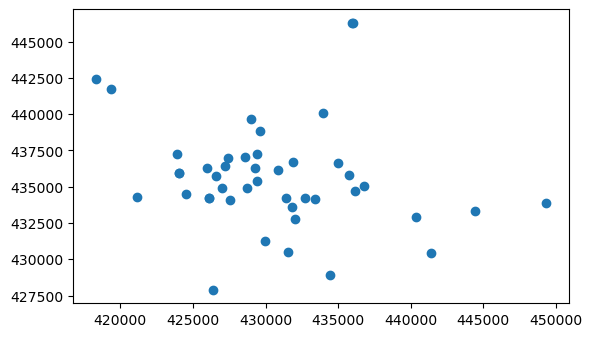

In [191]:
lgap_cgs.plot()

### B- Combining data

The LGAP data is combined with other existing CGSs data.

In [192]:
# Combine LGAP data with OS, OSM, LCC data into one df

if len(lgap_cgs) > 0:
    # Prepare LCC data for joining
    lgap_cgs_to_join = lgap_cgs[['globalid', 
                                 'organisation',
                                 'prof_vol', 
                                 'group_name',
                                 'activity_category',
                                 'activity_desc',
                                 'location',
                                 'day_time',
                                 'ongoing_or_program',
                                 'all_year',
                                 'seasonal_details',
                                 'one_location',
                                 'site_accessibility',
                                 'toilets',
                                 'indoor_space',
                                 'indoor_type',
                                 'indoor_other',
                                 'transport_support',
                                 'contact_name',
                                 'phone_number',
                                 'email',
                                 'website_link',
                                 'geometry']].copy()
    lgap_cgs_to_join['flag_LGAP'] = 'LGAP'
    lgap_cgs_to_join.columns = ['globalid', 
                                 'organisation',
                                 'prof_vol', 
                                 'group_name',
                                 'activity_category',
                                 'activity_desc',
                                 'location',
                                 'day_time',
                                 'ongoing_or_program',
                                 'all_year',
                                 'seasonal_details',
                                 'one_location',
                                 'site_accessibility',
                                 'toilets',
                                 'indoor_space',
                                 'indoor_type',
                                 'indoor_other',
                                 'transport_support',
                                 'contact_name',
                                 'phone_number',
                                 'email',
                                 'website_link',
                                 'geometry',
                                 'flag_LGAP']
    
    # Rename columns
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'group_name': 'Name (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'activity_category': 'Type (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'globalid': 'LGAP ID'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'organisation': 'Organisation (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'prof_vol': 'Management (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'activity_desc': 'Activity Description (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'location': 'Location Description (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'day_time': 'Day and Time (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'ongoing_or_program': 'Ongoing or set programs? (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'all_year': 'All year or seasonal? (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'seasonal_details': 'Seasonal details (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'one_location': 'one_location (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'site_accessibility': 'Site Accessibility (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'toilets': 'Toilets (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'indoor_space': 'Indoor Space (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'indoor_type': 'Indoor Type (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'transport_support': 'Transport Support (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'contact_name': 'Contact name (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'phone_number': 'Phone Number (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'email': 'Email (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'website_link': 'Website Link (LGAP)'})
    #Create column
    
    #Reorder columns
    lgap_cgs_to_join= lgap_cgs_to_join[['Name (LGAP)', 
                                        'Type (LGAP)', 
                                        'LGAP ID', 
                                        'Management (LGAP)',
                                        'Organisation (LGAP)',
                                        'Activity Description (LGAP)',
                                        'Location Description (LGAP)',
                                        'Day and Time (LGAP)',
                                        'Ongoing or set programs? (LGAP)',
                                        'All year or seasonal? (LGAP)',
                                        'Seasonal details (LGAP)',
                                        'one_location (LGAP)',
                                        'Site Accessibility (LGAP)',
                                        'Toilets (LGAP)',
                                        'Indoor Space (LGAP)',
                                        'Indoor Type (LGAP)',
                                        'Transport Support (LGAP)',
                                        'Contact name (LGAP)',
                                        'Phone Number (LGAP)',
                                        'Email (LGAP)',
                                        'Website Link (LGAP)',
                                        'geometry',
                                        'flag_LGAP']]

    # Ensure both datasets have the same CRS
    lgap_cgs_to_join= lgap_cgs_to_join.to_crs(final_exist_CGS.crs)

    # Combine LGAP data with OS+OSM+LCC data
    print("Combining LGAP data with CGSs...")
    Existing_CGSs = pd.concat([lgap_cgs_to_join, final_exist_CGS], ignore_index=True)
    
    # Create a unified flag for the data origin and remove temp flag columns 
    Existing_CGSs['flag_bis']= Existing_CGSs['flag'].fillna(Existing_CGSs['flag_LGAP'])
    Existing_CGSs = Existing_CGSs.drop(columns={'flag','flag_LGAP'})
    Existing_CGSs = Existing_CGSs.rename(columns={'flag_bis': 'flag'})
    
    print(f"Combined dataset: {len(Existing_CGSs)} features")
    print(f"  - LGAP features: {len(lgap_cgs_to_join)}")
    
else:
    print("No LGAP data available, using only OS, OSM and LCC data")
    Existing_CGSs = final_exist_CGS.copy()

Combining LGAP data with CGSs...
Combined dataset: 308 features
  - LGAP features: 44


## 5- Adding Fruit Works Co-operative Orchard data

This orchard data was provided by the [Fruit Works Co-operative](https://www.fruitworks.org.uk/) in Leeds. As the orchard data only contains postcodes, the [Ordnance Survey CodePointOpen](https://osdatahub.os.uk/data/downloads/open/CodePointOpen) dataset is used to geocode the postcodes.

### A- Formating data

In [193]:
FWC_path = f"{DATA_DIR}\Fruit_Works_Co\community orchards list.xlsx"
FWC = pd.read_excel(FWC_path)
FWC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  102 non-null    object
 1   Postcode    97 non-null     object
 2   W3W centre  88 non-null     object
 3   Ward        99 non-null     object
 4   Access      93 non-null     object
dtypes: object(5)
memory usage: 4.1+ KB


In [194]:
FWC['Postcode'].count()
#Expect to be able to map 86 orchards, others dont have postcodes and cannot be located

np.int64(97)

In [195]:
codepo_path = f"{DATA_DIR}\OS_codepo_gpkg_gb\Data\codepo_gb.gpkg"
codepo = gpd.read_file(codepo_path)
codepo.head()

,postcode,positional_quality_indicator,country_code,nhs_regional_ha_code,nhs_ha_code,admin_county_code,admin_district_code,admin_ward_code,geometry
0,AB10 1AB,10,S92000003,None,S08000020,None,S12000033,S13002842,POINT (394235 806529)
1,AB10 1AF,10,S92000003,None,S08000020,None,S12000033,S13002842,POINT (394235 806529)
2,AB10 1AG,10,S92000003,None,S08000020,None,S12000033,S13002842,POINT (394230 806469)
3,AB10 1AH,10,S92000003,None,S08000020,None,S12000033,S13002842,POINT (394235 806529)
4,AB10 1AL,10,S92000003,None,S08000020,None,S12000033,S13002842,POINT (394333 806529)


In [196]:
cols = ['postcode', 'geometry']
codepo = codepo[cols]
codepo = codepo.rename(columns={'postcode': 'Postcode'})

In [197]:
#Associated a geometry to each orchard using the postcode
FWC = FWC.merge(
    codepo,
    on='Postcode'
)
#Convert to GeoDataFrame
FWC = gpd.GeoDataFrame(FWC, geometry='geometry', crs='EPSG:27700')

FWC.head()

,Unnamed: 0,Postcode,W3W centre,Ward,Access,geometry
0,"Maid Marian orchard, Copley Lane",WF3 3AA,https://what3words.com/landed.holly.awards,Ardsley and Robin Hood,by arrangement,POINT (432623 427515)
1,Ouzlewell Orchard,WF3 3QP,https://what3words.com/wires.emerge.decay,Ardsley and Robin Hood,open,POINT (433850 426273)
2,Spring Lane Sidings,WF3 2BB,https://what3words.com/port.safely.damage,Ardsley and Robin Hood,open,POINT (430847 425482)
3,Beeston Hill,LS11 8LH,https://what3words.com/tins.legend.lazy,Beeston and Holbeck,open,POINT (429365 431422)
4,Cottingley x 3,LS11 0JT,https://what3words.com/monday.maple.held,Beeston and Holbeck,open,POINT (427370 430227)


In [198]:
FWC['Access'].value_counts()

Access
open              67
during the day     5
by arrangement     3
ticketed entry     2
for residents      1
Name: count, dtype: int64

In [199]:
FWC['geometry'].isna().sum()

np.int64(0)

In [200]:
FWC.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Unnamed: 0  86 non-null     object  
 1   Postcode    86 non-null     object  
 2   W3W centre  76 non-null     object  
 3   Ward        86 non-null     object  
 4   Access      78 non-null     object  
 5   geometry    86 non-null     geometry
dtypes: geometry(1), object(5)
memory usage: 4.2+ KB


### B- Combining data

In [201]:
# Combine orchard data with other data into one df

if len(FWC) > 0:
    # Prepare FWC data for joining
    FWC_to_join = FWC[['Unnamed: 0', 'Postcode', 'Access' , 'geometry']].copy()
    FWC_to_join['flag_FWC'] = 'FWC'
    FWC_to_join.columns = ['Unnamed: 0', 'Postcode', 'Access' , 'geometry', 'flag_FWC']

    # Rename columns
    FWC_to_join = FWC_to_join.rename(columns={'Unnamed: 0': 'Name (FWC)'})
    FWC_to_join = FWC_to_join.rename(columns={'Access': 'Access (FWC)'})
    FWC_to_join = FWC_to_join.rename(columns={'Postcode': 'Postcode (FWC)'})
    FWC_to_join['Type (FWC)'] = 'Orchard'

    #Reorder columns
    FWC_to_join= FWC_to_join[['Name (FWC)', 'Type (FWC)',  'Postcode (FWC)', 'Access (FWC)', 'geometry', 'flag_FWC']]

    # Ensure both datasets have the same CRS
    FWC_to_join= FWC_to_join.to_crs(Existing_CGSs.crs)

    # Combine data with FWC data
    print("Combining FWC data with other CGSs...")
    Existing_CGSs = pd.concat([FWC_to_join, Existing_CGSs], ignore_index=True)
    
    # Create a unified flag for the data origin and remove temp flag columns 
    Existing_CGSs['flag_bis']= Existing_CGSs['flag'].fillna(Existing_CGSs['flag_FWC'])
    Existing_CGSs = Existing_CGSs.drop(columns={'flag','flag_FWC'})
    Existing_CGSs = Existing_CGSs.rename(columns={'flag_bis': 'flag'})
    
    print(f"Combined dataset: {len(Existing_CGSs)} features")
    print(f"  - FWC features: {len(FWC_to_join)}")
    
else:
    print("No FWC data available")
    Existing_CGSs = Existing_CGSs.copy()

Combining FWC data with other CGSs...
Combined dataset: 394 features
  - FWC features: 86


In [202]:
Existing_CGSs.head()

,Name (FWC),Type (FWC),Postcode (FWC),Access (FWC),geometry,Name (LGAP),Type (LGAP),LGAP ID,Management (LGAP),Organisation (LGAP),Activity Description (LGAP),Location Description (LGAP),Day and Time (LGAP),Ongoing or set programs? (LGAP),All year or seasonal? (LGAP),Seasonal details (LGAP),one_location (LGAP),Site Accessibility (LGAP),Toilets (LGAP),Indoor Space (LGAP),Indoor Type (LGAP),Transport Support (LGAP),Contact name (LGAP),Phone Number (LGAP),Email (LGAP),Website Link (LGAP),cluster,Name (LCC),Type (LCC),LCC ID,Management (LCC),Email (LCC),Name (OS),Other name(s) (OS),Type (OS),OS ID,Name (OSM),Other name(s) (OSM),Type (OSM),OSM ID,flag
0,"Maid Marian orchard, Copley Lane",Orchard,WF3 3AA,by arrangement,POINT (432623 427515),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWC
1,Ouzlewell Orchard,Orchard,WF3 3QP,open,POINT (433850 426273),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWC
2,Spring Lane Sidings,Orchard,WF3 2BB,open,POINT (430847 425482),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWC
3,Beeston Hill,Orchard,LS11 8LH,open,POINT (429365 431422),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWC
4,Cottingley x 3,Orchard,LS11 0JT,open,POINT (427370 430227),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWC


## 6-Adding Feed Leeds/Urbal Map Data

Different datasets related to existing CGSs from the Urbal map are integrate:
* Bee Hives
* Community Growing Projects
* ~~Community Harvest~~ geometry not valid
* ~~Composting Sites~~ geometry not valid
* ~~Council Allotments~~ geometry not valid
* Edible Gardens (accessible)
* Edible Gardens (contact)
* Farm Visits
* ~~Food for Life Schools~~ not included
* Fruit and Nut Trees
* Green Groups Locations
* ~~LCC Sustainable Schools~~ not included
* LEC Food Patches
* Orchards and Forest Gardens
* ~~Other Allotments~~ geometry not valid
* Parks containing Edible Beds
* ~~Public Harvest~~ geometry not valid
* Resources (compost tools etc)
* Schools who Grow Food
* Schools with livestock
* Veg Growing

### A- Formating Data

In [203]:
#The map layers useful to identify existing CGS have been isolated in a folder
#files are loaded from this folder only if their geometries are valid
#all the files have the same column structure and can thus be concatenated into a single gdf

folder= Path(DATA_DIR)/"Urbal_Map_Layers_CGS"
gdfs= []

for file in folder.glob("*.kml"):
    try:
        gdf= gpd.read_file(file, driver="KML")
        #Add file name as Type column
        file_name= re.sub(r"[^\w]+", "_", file.stem).strip("_")
        gdf['Type']= file_name
        gdfs.append(gdf)
        print(f'Loaded: {file.name}')
    except Exception as e:
        print(f'Skipped: {file.name} ({e})')

Urbal_data = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs if gdfs else None
)

Loaded: 'Green_Groups'_Locations.kml
Loaded: Bee_Hives.kml
Loaded: Community_Growing_Projects.kml
Skipped: Community_Harvest.kml (IllegalArgumentException: Points of LinearRing do not form a closed linestring)
Skipped: Composting_site.kml (index 0 is out of bounds for axis 0 with size 0)
Skipped: Council_Allotments.kml (IllegalArgumentException: Points of LinearRing do not form a closed linestring)
Loaded: Edible_Gardens_(accessible).kml
Loaded: Edible_Gardens_(contact).kml
Loaded: Farm_Visits.kml
Loaded: Fruit_and_Nut_Trees.kml


c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
  return ogr_read(
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
  return ogr_read(


Loaded: LEC_Food_Patches.kml
Loaded: Orchards_+_Forest_Gardens.kml
Skipped: Other_Allotments.kml (IllegalArgumentException: Points of LinearRing do not form a closed linestring)
Loaded: Parks_containing_Edible_Beds.kml
Skipped: Public_Harvest.kml (IllegalArgumentException: Points of LinearRing do not form a closed linestring)
Loaded: Resources_(compost,_tools_etc).kml
Loaded: Schools_who_Grow_Food.kml
Loaded: Schools_wtih_livestock.kml
Loaded: Veg_Growing.kml


c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
  return ogr_read(
c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
  return ogr_read(


In [204]:
Urbal_data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            0 non-null      object        
 1   Name          333 non-null    object        
 2   description   333 non-null    object        
 3   timestamp     0 non-null      datetime64[ms]
 4   begin         0 non-null      datetime64[ms]
 5   end           0 non-null      datetime64[ms]
 6   altitudeMode  333 non-null    object        
 7   tessellate    333 non-null    int32         
 8   extrude       333 non-null    int32         
 9   visibility    333 non-null    int32         
 10  drawOrder     0 non-null      float64       
 11  icon          0 non-null      object        
 12  geometry      333 non-null    geometry      
 13  Type          333 non-null    object        
dtypes: datetime64[ms](3), float64(1), geometry(1), int32(3), object(6)
memory usage: 3

In [205]:
#Keep only non-empty columns/ columns with useful info
Urbal_data= Urbal_data[['Type', 'Name', 'description', 'geometry']]
Urbal_data.head()

,Type,Name,description,geometry
0,Green_Groups__Locations,Able Project. Food growing in,Able Project. Food growing in Wakefield\n\nht...,POINT (-1.47973 53.67776)
1,Green_Groups__Locations,Deliciously Yorkshire http://deliciouslyorkshi...,Deliciously Yorkshire http://deliciouslyorksh...,POINT (-1.16164 53.92103)
2,Green_Groups__Locations,Instaplanta - http://www.instaplanta.co.uk/,Instaplanta - http://www.instaplanta.co.uk/,POINT (-0.29018 53.74887)
3,Green_Groups__Locations,Leeds beekeepers Association (Winter meetings),Leeds beekeepers Association (Winter meetings...,POINT (-1.453 53.80592)
4,Green_Groups__Locations,Leeds Horticultural Society - http://www.leeds...,Leeds Horticultural Society - http://www.leed...,POINT (-1.58615 53.82854)


In [206]:
#The website links are extracted from the descrition column into a 'Website Link (Urbal)' column
# extract() extracts single link per cell
# https?:// matches htpp and htpps
# \S+ keeps going until whitespace
Urbal_data['Website Link (Urbal)']= Urbal_data['description'].str.extract(r"(https?://\S+)", expand=False)
#And remove URLs from the description column
Urbal_data['description'] = (
    Urbal_data['description']
    .str.replace(r"https?://\S+", "", regex=True)
    .str.strip() #remove spaces at start and end of info
    .str.replace(r"</?b>", "", regex=True)
    .str.replace(r"\s+", " ", regex=True) #remove whitespace
)
#And remove URLs from the name column
Urbal_data['Name'] = (
    Urbal_data['Name']
    .str.replace(r"https?://\S+", "", regex=True)
    .str.strip() #remove spaces at start and end of info
    .str.replace(r"</?b>", "", regex=True)
    .str.replace(r"\s+", " ", regex=True) #remove whitespace
)
Urbal_data.head()

,Type,Name,description,geometry,Website Link (Urbal)
0,Green_Groups__Locations,Able Project. Food growing in,Able Project. Food growing in Wakefield,POINT (-1.47973 53.67776),http://www.theableproject.org.uk/
1,Green_Groups__Locations,Deliciously Yorkshire,Deliciously Yorkshire,POINT (-1.16164 53.92103),http://deliciouslyorkshire.co.uk/
2,Green_Groups__Locations,Instaplanta -,Instaplanta -,POINT (-0.29018 53.74887),http://www.instaplanta.co.uk/
3,Green_Groups__Locations,Leeds beekeepers Association (Winter meetings),Leeds beekeepers Association (Winter meetings),POINT (-1.453 53.80592),http://www.leedsbeekeepers.org.uk/
4,Green_Groups__Locations,Leeds Horticultural Society -,Leeds Horticultural Society -,POINT (-1.58615 53.82854),http://www.leedshs.org.uk/


In [207]:
Urbal_data['description'].unique()

array(['Able Project. Food growing in Wakefield', 'Deliciously Yorkshire',
       'Instaplanta -', 'Leeds beekeepers Association (Winter meetings)',
       'Leeds Horticultural Society -', 'Edible Cities',
       'Permaculture Association', 'TCV -',
       'Leeds Permaculture Network - meet at Waterways bldg (now Canal and Rivers Trust)',
       'PuLSE aimed at increasing the resilience of Pudsey. We suport each other to develop sustainbility project ideas and make things happen. We have a monthly education and social evening, seed and seedling swaps, tree plantings, fruit picking, wild food walks and are setting up a food co-op. We are also part of Leeds Permaculture Network and we are a Permaculture LAND demonstration project, with a focus on home scale urban sustainability.',
       "Transition Meanwood - currently meeting in the Waitrose Café, and over the road in the East of Arcadia Pub Restaurant. Run a good e-list and calendar (link on the Urbal Calendar page. Transition Meanwoo

In [208]:
Urbal_data['Type'].value_counts()

Type
Community_Growing_Projects       71
Schools_who_Grow_Food            54
Orchards___Forest_Gardens        38
Resources__compost__tools_etc    27
LEC_Food_Patches                 26
Veg_Growing                      22
Parks_containing_Edible_Beds     17
Edible_Gardens__accessible       16
Green_Groups__Locations          14
Schools_wtih_livestock           12
Farm_Visits                      11
Fruit_and_Nut_Trees              11
Bee_Hives                         8
Edible_Gardens__contact           6
Name: count, dtype: int64

### B- Combining Data

In [209]:
Existing_CGSs.columns

Index(['Name (FWC)', 'Type (FWC)', 'Postcode (FWC)', 'Access (FWC)',
       'geometry', 'Name (LGAP)', 'Type (LGAP)', 'LGAP ID',
       'Management (LGAP)', 'Organisation (LGAP)',
       'Activity Description (LGAP)', 'Location Description (LGAP)',
       'Day and Time (LGAP)', 'Ongoing or set programs? (LGAP)',
       'All year or seasonal? (LGAP)', 'Seasonal details (LGAP)',
       'one_location (LGAP)', 'Site Accessibility (LGAP)', 'Toilets (LGAP)',
       'Indoor Space (LGAP)', 'Indoor Type (LGAP)', 'Transport Support (LGAP)',
       'Contact name (LGAP)', 'Phone Number (LGAP)', 'Email (LGAP)',
       'Website Link (LGAP)', 'cluster', 'Name (LCC)', 'Type (LCC)', 'LCC ID',
       'Management (LCC)', 'Email (LCC)', 'Name (OS)', 'Other name(s) (OS)',
       'Type (OS)', 'OS ID', 'Name (OSM)', 'Other name(s) (OSM)', 'Type (OSM)',
       'OSM ID', 'flag'],
      dtype='object')

In [210]:
# Combine Urbal data with other data into one df

if len(Urbal_data) > 0:
    # Prepare Urbal data for joining
    Urbal_to_join = Urbal_data[['Type', 'Name', 'description', 'geometry', 'Website Link (Urbal)']].copy()
    Urbal_to_join['flag_Urbal'] = 'Urbal'
    Urbal_to_join.columns = ['Type', 'Name', 'description', 'geometry', 'Website Link (Urbal)', 'flag_Urbal']

    # Rename columns
    Urbal_to_join = Urbal_to_join.rename(columns={'Type': 'Type (Urbal)'})
    Urbal_to_join = Urbal_to_join.rename(columns={'Name': 'Name (Urbal)'})
    Urbal_to_join = Urbal_to_join.rename(columns={'description': 'Description (Urbal)'})

    #Reorder columns
    Urbal_to_join= Urbal_to_join[['flag_Urbal', 'Type (Urbal)', 'Name (Urbal)', 'geometry', 'Description (Urbal)', 'Website Link (Urbal)']]

    # Ensure both datasets have the same CRS
    Urbal_to_join= Urbal_to_join.to_crs(Existing_CGSs.crs)

    # Combine data with Urbal data
    print("Combining Urbal data with other CGSs...")
    Existing_CGSs = pd.concat([Urbal_to_join, Existing_CGSs], ignore_index=True)
    
    # Create a unified flag for the data origin and remove temp flag columns 
    Existing_CGSs['flag_bis']= Existing_CGSs['flag'].fillna(Existing_CGSs['flag_Urbal'])
    Existing_CGSs = Existing_CGSs.drop(columns={'flag','flag_Urbal'})
    Existing_CGSs = Existing_CGSs.rename(columns={'flag_bis': 'flag'})
    
    print(f"Combined dataset: {len(Existing_CGSs)} features")
    print(f"  - Urbal features: {len(Urbal_to_join)}")
    
else:
    print("No Urbal data available")
    Existing_CGSs = Existing_CGSs.copy()

Combining Urbal data with other CGSs...
Combined dataset: 727 features
  - Urbal features: 333


In [211]:
Existing_CGSs.head()

,Type (Urbal),Name (Urbal),geometry,Description (Urbal),Website Link (Urbal),Name (FWC),Type (FWC),Postcode (FWC),Access (FWC),Name (LGAP),Type (LGAP),LGAP ID,Management (LGAP),Organisation (LGAP),Activity Description (LGAP),Location Description (LGAP),Day and Time (LGAP),Ongoing or set programs? (LGAP),All year or seasonal? (LGAP),Seasonal details (LGAP),one_location (LGAP),Site Accessibility (LGAP),Toilets (LGAP),Indoor Space (LGAP),Indoor Type (LGAP),Transport Support (LGAP),Contact name (LGAP),Phone Number (LGAP),Email (LGAP),Website Link (LGAP),cluster,Name (LCC),Type (LCC),LCC ID,Management (LCC),Email (LCC),Name (OS),Other name(s) (OS),Type (OS),OS ID,Name (OSM),Other name(s) (OSM),Type (OSM),OSM ID,flag
0,Green_Groups__Locations,Able Project. Food growing in,POINT (434464.76 420269.115),Able Project. Food growing in Wakefield,http://www.theableproject.org.uk/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Urbal
1,Green_Groups__Locations,Deliciously Yorkshire,POINT (455157.001 447535.672),Deliciously Yorkshire,http://deliciouslyorkshire.co.uk/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Urbal
2,Green_Groups__Locations,Instaplanta -,POINT (512847.015 429412.283),Instaplanta -,http://www.instaplanta.co.uk/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Urbal
3,Green_Groups__Locations,Leeds beekeepers Association (Winter meetings),POINT (436120.821 434540.99),Leeds beekeepers Association (Winter meetings),http://www.leedsbeekeepers.org.uk/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Urbal
4,Green_Groups__Locations,Leeds Horticultural Society -,POINT (427337.252 436999.163),Leeds Horticultural Society -,http://www.leedshs.org.uk/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Urbal


## 6- Formating data for Dashboard building

The previously combined dataset is formated to only include the information required to create a dashboard of existing CGSs.

In [212]:
Existing_CGSs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 727 entries, 0 to 726
Data columns (total 45 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   Type (Urbal)                     333 non-null    object  
 1   Name (Urbal)                     333 non-null    object  
 2   geometry                         727 non-null    geometry
 3   Description (Urbal)              333 non-null    object  
 4   Website Link (Urbal)             144 non-null    object  
 5   Name (FWC)                       86 non-null     object  
 6   Type (FWC)                       86 non-null     object  
 7   Postcode (FWC)                   86 non-null     object  
 8   Access (FWC)                     78 non-null     object  
 9   Name (LGAP)                      44 non-null     object  
 10  Type (LGAP)                      44 non-null     object  
 11  LGAP ID                          44 non-null     object  
 12  

In [213]:
#Visualize the cleaned dataset of existing CGSs
Existing_CGSs.explore('flag', tooltip=['Type (Urbal)', 'Type (OS)','Type (OSM)', 'Type (LCC)', 'Type (LGAP)', 'Type (FWC)'], alpha=0.5)

### A- Format single values per rows

In [214]:
#Combining columns, where there is only one value per row

#Take first non-empty value
Existing_CGSs['Management'] =(
    Existing_CGSs[['Management (LGAP)', 'Management (LCC)']]
    .bfill(axis= 1) #fill missing values
    .iloc[:, 0] #Take first non-empty value
)

Existing_CGSs['Email'] =(
    Existing_CGSs[['Email (LGAP)', 'Email (LCC)']]
    .bfill(axis= 1) #fill missing values
    .iloc[:, 0] #Take first non-empty value
)

Existing_CGSs['Description'] =(
    Existing_CGSs[['Description (Urbal)', 'Activity Description (LGAP)']]
    .bfill(axis= 1) #fill missing values
    .iloc[:, 0] #Take first non-empty value
)

Existing_CGSs['Website_Link'] =(
    Existing_CGSs[['Website Link (Urbal)', 'Website Link (LGAP)']]
    .bfill(axis= 1) #fill missing values
    .iloc[:, 0] #Take first non-empty value
)


#Drop columns
Existing_CGSs = Existing_CGSs.drop(columns= ['Management (LGAP)', 
                                             'Management (LCC)',
                                             'Email (LGAP)', 
                                             'Email (LCC)',
                                             'Description (Urbal)', 
                                             'Activity Description (LGAP)', 
                                             'Website Link (Urbal)',
                                             'Website Link (LGAP)'])

In [215]:
#Drop irrelevant columns
Existing_CGSs = Existing_CGSs.drop(columns='cluster')

### B- Format several values per rows

The type of Community Growing Scheme is formatted and combined to have a single value per row.

In [216]:
#Create function to replace text values across several columns (helps cleaning)

def replace_text (df, columns, old_value, new_value):
    """
    Parameters
    df: dataframe
    columns: list of columns to modify
    old_value: str text to replace
    new_value: str replacement text
    """
    
    for col in columns:
        df[col] = df[col].replace(old_value, new_value)
    
    return df

In [217]:
#Format all 'Type' columns with allotments text entries as 'Allotments'
cols = ['Type (LGAP)', 'Type (LCC)', 'Type (OS)', 'Type (OSM)', 'Type (FWC)', 'Type (Urbal)']

Existing_CGSs = replace_text(
    Existing_CGSs,
    columns= cols,
    old_value='allotments',
    new_value= 'Allotments'
)

In [218]:
#Combining Type columns
#Here the LCC 'Allotments' entry takes priority 

cols = ['Type (LGAP)', 'Type (LCC)', 'Type (OS)', 'Type (OSM)', 'Type (FWC)', 'Type (Urbal)']
priority_value = 'Allotments'

def combine_text(row):
    values= []
    #Combine all non-null text
    for v in row:
        if pd.isna(v):
            continue
        
        v = str(v).strip()
        if v == '' or v.lower()== 'none' or v.lower()== 'nan':
            continue
        
        values.append(v)
        
        #Priority rule
    if priority_value in values:
        return priority_value
    
    return ' | '.join(values)

#Run function
Existing_CGSs['Type']= Existing_CGSs[cols].apply(combine_text, axis=1)
#Drop columns
Existing_CGSs = Existing_CGSs.drop(columns= cols)

In [219]:
Existing_CGSs['Type'].value_counts()

Type
Allotments                                174
Orchard                                    86
community                                  73
Community_Growing_Projects                 71
Schools_who_Grow_Food                      54
Gardening                                  42
Orchards___Forest_Gardens                  38
Resources__compost__tools_etc              27
LEC_Food_Patches                           26
Veg_Growing                                22
Parks_containing_Edible_Beds               17
Edible_Gardens__accessible                 16
Green_Groups__Locations                    14
Schools_wtih_livestock                     12
Fruit_and_Nut_Trees                        11
Farm_Visits                                11
Allotments Or Community Growing Spaces     10
Bee_Hives                                   8
Edible_Gardens__contact                     6
orchard                                     5
community, orchard                          2
Gardening and Animal Care    

In [220]:
Existing_CGSs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 727 entries, 0 to 726
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   Name (Urbal)                     333 non-null    object  
 1   geometry                         727 non-null    geometry
 2   Name (FWC)                       86 non-null     object  
 3   Postcode (FWC)                   86 non-null     object  
 4   Access (FWC)                     78 non-null     object  
 5   Name (LGAP)                      44 non-null     object  
 6   LGAP ID                          44 non-null     object  
 7   Organisation (LGAP)              44 non-null     object  
 8   Location Description (LGAP)      44 non-null     object  
 9   Day and Time (LGAP)              44 non-null     object  
 10  Ongoing or set programs? (LGAP)  44 non-null     object  
 11  All year or seasonal? (LGAP)     44 non-null     object  
 12  

The name of each Community Growing Scheme is formatted and combined to have a single value per row.

In [221]:
#Create text standardization function
def standard_text(text):
    text= str(text).lower() #use all lower case
    text= text.strip() #remove spaces
    #Remove punctuation, special characters, and numbers
    #Keep only letters a to z, and spaces \s
    text= re.sub(r"[^a-z\s]", "", text)
    #Remove extra whitespace (spaces, tabs, newlines, multiple spaces)
    text= re.sub(r"\s+", " ", text).strip()
    
    return text

Here I take a two keys approach:
1) a token key (with spaces) for fuzzy token matching (e.g. springfield allotments == rothwell springfield street allotments)
2) a compact key (without spaces) for merged-word matching (e.g. white house allotments == whitehouse allotments)

In [222]:
#Create fucntion for key token comparison for fuzzy token matching
#keeping spaces

def token_key(text):
    text= standard_text(text) #run previous function
    
    #Remove generic words
    remove_words= [
        'allotments',
        'allotment',
        'street',
        'lane',
        'road',
        'gardens',
        'garden',
        'community orchard',
        'orchard'
    ]
    
    #Split into words and remove noise words
    words= [w for w in text.split() if w not in remove_words]
    
#Rebuild cleaned name
    return " ".join(words)

#-------------------------------------------------------------------

#Create function for compact key (without spaces)
#takes the cleaned token version and removes spaces
def compact_key(text):
    return token_key(text).replace(" ", "")

In [223]:
pip install rapidfuzz

Note: you may need to restart the kernel to use updated packages.


In [224]:
#Create function for row-level deduplication of messy place names 
# using fuzzy matching
# and two different similarity systems
# so for each row, multiple name columns are combined into a single clean name
from rapidfuzz import fuzz

#process one row at a time
#90% similarity threshold
def combine_names(row, threshold= 90):
    unique_names= [] #store the final cleaned names
    seen_token_keys= [] #store the comparison word-based versions of names, used for fuzzy matching
    seen_compact_keys= [] #store no-space versions
    
    #Loop through all name columns (LGAP, LCC, OS, OSM)
    for col in cols:
        val = row.get(col)
        
        #Skip empty values
        if pd.notna(val):
            #Use standardizing string function
            clean = standard_text(val)
            
            #Skip to next column if cleaned string is empty
            if not clean:
                continue
            
            #Create two comparison keys
            tkey= token_key(clean)
            ckey= compact_key(clean)
            #Assumes name is not a duplicate initially, will change to True if match is found
            matched= False
            
            #Compare against already accepted names
            #Loops throuhg all previously accepted names (for this row)
            for i, existing_tkey in enumerate(seen_token_keys):
                existing_ckey= seen_compact_keys[i]
                #Computes similarity between two strings
                score= fuzz.token_set_ratio(tkey, existing_tkey)
                
                #Split the tokens (of current name and previous accepted names)
                tokens1= set(tkey.split())
                tokens2= set(existing_tkey.split())
                #Overlap ratio
                #how much the smaller name is contained in the larger name?
                overlap= len(tokens1 & tokens2) / min(len(tokens1), len(tokens2))
                
                #Decide of they are the same
                similar= (
                    score >= threshold or #if strong fuzzy match
                    overlap >= 0.8 or #if high token overlap 80% shared words
                    ckey == existing_ckey or #exact compact match
                    ckey in existing_ckey or #one contains the other
                    existing_ckey in ckey
                )
                
                if similar:
                    matched= True
                    
                    #Keep the longest/more descriptive version of name
                    if len(clean) > len(unique_names[i]):
                        unique_names[i] = clean
                        seen_token_keys[i]= tkey
                        seen_compact_keys[i]= ckey
                    break
                            
            #If no match, add clean name to final output list and store key
            if not matched:
                unique_names.append(clean)
                seen_token_keys.append(tkey)
                seen_compact_keys.append(ckey)
    
    #Join all unique names into a single string
    return " | ".join(unique_names) if unique_names else None


In [225]:
#Run the function on the different name columns

cols = ['Name (LGAP)', 
        'Name (LCC)', 
        'Name (OS)', 
        'Name (OSM)', 
        'Name (FWC)',
        'Name (Urbal)']

Existing_CGSs['Name']= Existing_CGSs[cols].apply(combine_names, axis=1)

#Drop old name columns
Existing_CGSs = Existing_CGSs.drop(columns= cols)
Existing_CGSs.head()

,geometry,Postcode (FWC),Access (FWC),LGAP ID,Organisation (LGAP),Location Description (LGAP),Day and Time (LGAP),Ongoing or set programs? (LGAP),All year or seasonal? (LGAP),Seasonal details (LGAP),one_location (LGAP),Site Accessibility (LGAP),Toilets (LGAP),Indoor Space (LGAP),Indoor Type (LGAP),Transport Support (LGAP),Contact name (LGAP),Phone Number (LGAP),LCC ID,Other name(s) (OS),OS ID,Other name(s) (OSM),OSM ID,flag,Management,Email,Description,Website_Link,Type,Name
0,POINT (434464.76 420269.115),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Urbal,NaN,NaN,Able Project. Food growing in Wakefield,http://www.theableproject.org.uk/,Green_Groups__Locations,able project food growing in
1,POINT (455157.001 447535.672),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Urbal,NaN,NaN,Deliciously Yorkshire,http://deliciouslyorkshire.co.uk/,Green_Groups__Locations,deliciously yorkshire
2,POINT (512847.015 429412.283),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Urbal,NaN,NaN,Instaplanta -,http://www.instaplanta.co.uk/,Green_Groups__Locations,instaplanta
3,POINT (436120.821 434540.99),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Urbal,NaN,NaN,Leeds beekeepers Association (Winter meetings),http://www.leedsbeekeepers.org.uk/,Green_Groups__Locations,leeds beekeepers association winter meetings
4,POINT (427337.252 436999.163),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Urbal,NaN,NaN,Leeds Horticultural Society -,http://www.leedshs.org.uk/,Green_Groups__Locations,leeds horticultural society


In [226]:
Existing_CGSs['Name'].unique()

array(['able project food growing in', 'deliciously yorkshire',
       'instaplanta', 'leeds beekeepers association winter meetings',
       'leeds horticultural society', 'edible cities',
       'permaculture association', 'tcv',
       'leeds permaculture network meet', 'pulse aimed at increasing',
       'transition meanwood currently meeting', 'back to front',
       'roseville leopold st cohousing',
       'groundwork leeds a community charity',
       'leeds beekeepers association summer meetings',
       'university beehives school', 'hollybush farm hives',
       'the queens hotel beehives we write',
       'beehives are planned for the', 'leeds beekeepers apiary',
       'beehives here were devastated in', 'st georges field apiary',
       'new shoots garden group bracken edge', 'feel good factor',
       'gledhow field state of original gledhow',
       'st georges crypt garden sorry link', 'faith lodge st georges',
       'the growing zone allotment', 'marlborough green roof

In [227]:
#Replace text inside names to standardize plurals/singular difference
def replace_within_cell(df, columns, old_value, new_value):
    pattern= rf"\b{re.escape(old_value)}\b"
    for col in cols:
        df[col]= df[col].str.replace(
            pattern,
            new_value,
            regex= True
        )
    return df

#Lots of names have 'allotment' or 'allotments', so need to standardize
#Run the function on the different name columns

cols = ['Name']

Existing_CGSs = replace_within_cell(
    Existing_CGSs,
    columns= cols,
    old_value='allotment',
    new_value= 'allotments'
)

In [228]:
Existing_CGSs['Name'].unique()

array(['able project food growing in', 'deliciously yorkshire',
       'instaplanta', 'leeds beekeepers association winter meetings',
       'leeds horticultural society', 'edible cities',
       'permaculture association', 'tcv',
       'leeds permaculture network meet', 'pulse aimed at increasing',
       'transition meanwood currently meeting', 'back to front',
       'roseville leopold st cohousing',
       'groundwork leeds a community charity',
       'leeds beekeepers association summer meetings',
       'university beehives school', 'hollybush farm hives',
       'the queens hotel beehives we write',
       'beehives are planned for the', 'leeds beekeepers apiary',
       'beehives here were devastated in', 'st georges field apiary',
       'new shoots garden group bracken edge', 'feel good factor',
       'gledhow field state of original gledhow',
       'st georges crypt garden sorry link', 'faith lodge st georges',
       'the growing zone allotments', 'marlborough green roo

In [229]:
Existing_CGSs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 727 entries, 0 to 726
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   geometry                         727 non-null    geometry
 1   Postcode (FWC)                   86 non-null     object  
 2   Access (FWC)                     78 non-null     object  
 3   LGAP ID                          44 non-null     object  
 4   Organisation (LGAP)              44 non-null     object  
 5   Location Description (LGAP)      44 non-null     object  
 6   Day and Time (LGAP)              44 non-null     object  
 7   Ongoing or set programs? (LGAP)  44 non-null     object  
 8   All year or seasonal? (LGAP)     44 non-null     object  
 9   Seasonal details (LGAP)          5 non-null      object  
 10  one_location (LGAP)              43 non-null     object  
 11  Site Accessibility (LGAP)        37 non-null     object  
 12  

### C- Remove, rename and reorganize columns

In [230]:
#Check 'Other name(s) (OSM) rows
filtered= Existing_CGSs[Existing_CGSs['Other name(s) (OSM)'].notna()]
filtered.head()

,geometry,Postcode (FWC),Access (FWC),LGAP ID,Organisation (LGAP),Location Description (LGAP),Day and Time (LGAP),Ongoing or set programs? (LGAP),All year or seasonal? (LGAP),Seasonal details (LGAP),one_location (LGAP),Site Accessibility (LGAP),Toilets (LGAP),Indoor Space (LGAP),Indoor Type (LGAP),Transport Support (LGAP),Contact name (LGAP),Phone Number (LGAP),LCC ID,Other name(s) (OS),OS ID,Other name(s) (OSM),OSM ID,flag,Management,Email,Description,Website_Link,Type,Name
504,"MULTIPOLYGON (((435638.45 435836.3, 435660.2 4...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GRN00232,NaN,49E9C762-967D-A491-E063-8CCAA00A0EF3,St James Allotments,None,LCC_OS_OSM,Council controlled,mailto:allotments@leeds.gov.uk,NaN,NaN,Allotments,st james allotments | brooklands allotments


In [231]:
#And drop this column (name is already in 'Name' column)
Existing_CGSs= Existing_CGSs.drop(columns='Other name(s) (OSM)')

In [232]:
#Check 'Other name(s) (OS) rows
filtered= Existing_CGSs[Existing_CGSs['Other name(s) (OS)'].notna()]
filtered.head()

,geometry,Postcode (FWC),Access (FWC),LGAP ID,Organisation (LGAP),Location Description (LGAP),Day and Time (LGAP),Ongoing or set programs? (LGAP),All year or seasonal? (LGAP),Seasonal details (LGAP),one_location (LGAP),Site Accessibility (LGAP),Toilets (LGAP),Indoor Space (LGAP),Indoor Type (LGAP),Transport Support (LGAP),Contact name (LGAP),Phone Number (LGAP),LCC ID,Other name(s) (OS),OS ID,OSM ID,flag,Management,Email,Description,Website_Link,Type,Name


In [233]:
#And drop this column (name is already in 'Name' column)
Existing_CGSs= Existing_CGSs.drop(columns='Other name(s) (OS)')

In [234]:
Existing_CGSs.columns

Index(['geometry', 'Postcode (FWC)', 'Access (FWC)', 'LGAP ID',
       'Organisation (LGAP)', 'Location Description (LGAP)',
       'Day and Time (LGAP)', 'Ongoing or set programs? (LGAP)',
       'All year or seasonal? (LGAP)', 'Seasonal details (LGAP)',
       'one_location (LGAP)', 'Site Accessibility (LGAP)', 'Toilets (LGAP)',
       'Indoor Space (LGAP)', 'Indoor Type (LGAP)', 'Transport Support (LGAP)',
       'Contact name (LGAP)', 'Phone Number (LGAP)', 'LCC ID', 'OS ID',
       'OSM ID', 'flag', 'Management', 'Email', 'Description', 'Website_Link',
       'Type', 'Name'],
      dtype='object')

Reorder columns for clarity.

In [235]:
#Reorder the columns for clarity
Existing_CGSs = Existing_CGSs[[
                         'flag',
                         'Type',
                         'Name',
                         'geometry',
                         'Management',
                         'Organisation (LGAP)',
                         'Description',
                         
                         'Access (FWC)',
                         'Day and Time (LGAP)',
                         'Ongoing or set programs? (LGAP)',
                         'All year or seasonal? (LGAP)',
                         'Seasonal details (LGAP)',
                         'one_location (LGAP)',
                         'Location Description (LGAP)',
                         'Postcode (FWC)',
                         
                         'Site Accessibility (LGAP)',
                         'Toilets (LGAP)',
                         'Indoor Space (LGAP)',
                         'Indoor Type (LGAP)',
                         'Transport Support (LGAP)',
                         
                         'Contact name (LGAP)',
                         'Email',
                         'Phone Number (LGAP)',
                         'Website_Link',
                         
                         'OS ID',
                         'OSM ID',
                         'LCC ID',
                         'LGAP ID'
                         ]]

Avoid confusion between the different accessibility columns.

In [236]:
#Rename columns for clarity
#The 'Site Accessibility (LGAP)' column refers to mobility/wheelchair access
# BUT
#The 'Access (FWC)' column refers to entry conditions

Existing_CGSs = Existing_CGSs.rename(columns={'Access (FWC)': 'Entry_Conditions'})

### D- Formating the 'Type' of CGSs

In [237]:
Existing_CGSs['Type'].unique()

array(['Green_Groups__Locations', 'Bee_Hives',
       'Community_Growing_Projects', 'Edible_Gardens__accessible',
       'Edible_Gardens__contact', 'Farm_Visits', 'Fruit_and_Nut_Trees',
       'LEC_Food_Patches', 'Orchards___Forest_Gardens',
       'Parks_containing_Edible_Beds', 'Resources__compost__tools_etc',
       'Schools_who_Grow_Food', 'Schools_wtih_livestock', 'Veg_Growing',
       'Orchard', 'Gardening', 'Gardening and Animal Care',
       'Farm-Scale Vegetable Growing', 'Allotments',
       'Allotments Or Community Growing Spaces', 'community', 'orchard',
       'community, orchard'], dtype=object)

In [238]:
#Standardize type values for orchards
# so that 'Orchard' , 'orchard' and 'community, orchard' all fall under the same type
Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
    'Orchards___Forest_Gardens': 'Community Orchard',
    'Orchard': 'Community Orchard',
    'community, orchard': 'Community Orchard',
    'orchard': 'Community Orchard',
})

In [239]:
#Standardize type values for community growing spaces
# as the allotments took priority when joining together OS, OSM and LCC data
# I assume that the types left in 'Allotments Or Community Growing Spaces' should now all be Community Growing Spaces
Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
    'Allotments Or Community Growing Spaces': 'Community Growing Spaces'
})

#The 'community' feature from OSM is also standardized
Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
    'community': 'Community Growing Spaces'
})

In [240]:
#Rename LGAP as these are activities that occur rather than places
# and align with the Urbal 'Community_Growing_Projects' type
Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
    'Gardening': 'Community_Growing_Projects'
})

In [241]:
#Join together farm activities
Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
    'Gardening and Animal Care': 'Farm'
})

Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
    'Farm-Scale Vegetable Growing': 'Farm'
})

Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
    'Farm_Visits': 'Farm'
})

In [253]:
filtered = Existing_CGSs[Existing_CGSs['Type'] == 'Green_Groups__Locations']
filtered['Name'].unique()

array(['able project food growing in', 'deliciously yorkshire',
       'instaplanta', 'leeds beekeepers association winter meetings',
       'leeds horticultural society', 'edible cities',
       'permaculture association', 'tcv',
       'leeds permaculture network meet', 'pulse aimed at increasing',
       'transition meanwood currently meeting', 'back to front',
       'roseville leopold st cohousing',
       'groundwork leeds a community charity'], dtype=object)

In [244]:
Existing_CGSs['Type'].value_counts()

Type
Allotments                       174
Community Orchard                131
Community_Growing_Projects       113
Community Growing Spaces          83
Schools_who_Grow_Food             54
Resources__compost__tools_etc     27
LEC_Food_Patches                  26
Veg_Growing                       22
Parks_containing_Edible_Beds      17
Edible_Gardens__accessible        16
Green_Groups__Locations           14
Farm                              13
Schools_wtih_livestock            12
Fruit_and_Nut_Trees               11
Bee_Hives                          8
Edible_Gardens__contact            6
Name: count, dtype: int64

In [245]:
#Correct the 'Type' of CGS if orchard appears in name
mask = (Existing_CGSs['Name'].str.contains('orchard', case=False, na=False))

Existing_CGSs.loc[mask, 'Type'] = 'Community Orchard'

#Correct the 'Type' of CGS if farm appears in name
mask = (Existing_CGSs['Name'].str.contains('farm', case=False, na=False))

Existing_CGSs.loc[mask, 'Type'] = 'Farm'

### E- Create a unique ID for each CGS
(Optional: to keep track of where the data comes from if combined)

In [247]:
# Define function to create a unique 5 digit ID for each local authority 
# (useful if scaling but not needed here)

# def make_la_code_5(name, existing=None):
#     if existing is None:
#         existing = set()
    
#     # --- Clean ---
#     clean = re.sub(r"[^A-Za-z\s]", "", str(name))
#     clean = re.sub(r"\s+", " ", clean).strip().upper()
    
#     words = clean.split()
    
#     # --- Remove filler words ---
#     stopwords = {
#         "OF", "THE","AND", "CITY", "BOROUGH", "DISTRICT",
#         "COUNCIL", "METROPOLITAN", "LONDON", "COUNTY"
#     }
#     words = [w for w in words if w not in stopwords] or words
    
#     # --- Build base safely ---
#     if len(words) == 1:
#         base = words[0][:5]
#     else:
#         # Take first letters of each word
#         base = "".join(w[:3] for w in words)
        
#         # If too short, pad with more letters from first word
#         if len(base) < 5:
#             extra = words[0][1:5]
#             base = (base + extra)[:5]
#         else:
#             base = base[:5]
    
#     code = base
    
#     # --- Ensure uniqueness ---
#     i = 5
#     while code in existing:
#         code = (base[:4] + str(i))[:5]
#         i += 1
    
#     existing.add(code)
#     return code
# # Define 5 letter code for Local authority (in this case Leeds)
# existing_codes = set()

# LAD_2024["LA_CODE"] = LAD_2024['LAD24NM'].apply(
#     lambda x: make_la_code_5(x, existing_codes)
# )    

# if LAD_2024['LA_CODE'].nunique()== LAD_2024.shape[0]:
#     print('Success: unique LA_CODE for each Local Authority')
# else: 
#     print('WARNING: LA_CODE not unique')


# LA_CODE = LAD_2024.loc[LAD_2024['LAD24NM']== LOCAL_AUTHORITY_NAME, 'LA_CODE'].values[0]



In [248]:
# Create a unique ID for each CGS
LA_CODE = 'LEEDS'
USER_STRING = LA_CODE  # use LA code to define unique ID for each CGS joined from all 3 sources

def row_hash_with_user(row, user_string, hash_len=12):
    """
    Create a unique ID for each row that contains the user string.
    """
    # 1. Convert row to string
    row_str = "|".join(map(str, row.values))
    
    # 2. Combine with user string for hashing
    full_str = f"{user_string}|{row_str}"
    
    # 3. Compute hash and truncate
    hash_part = hashlib.sha256(full_str.encode()).hexdigest()[:hash_len]
    
    # 4. Return ID: prefix with user string for clarity
    return f"{user_string}_{hash_part}"

# Apply to DataFrame
Existing_CGSs["id"] = Existing_CGSs.apply(
    lambda r: row_hash_with_user(r, USER_STRING, hash_len=12),
    axis=1
)
# Save look-up table
Existing_CGSs[['OS ID','OSM ID', 'LCC ID', 'LGAP ID', 'id']].to_csv(os.path.join(DATA_DIR, f'{LA_CODE}_lookup.csv'), index=False)

#Drop old ID columns
Existing_CGSs= Existing_CGSs.drop(columns=['OS ID','OSM ID', 'LCC ID', 'LGAP ID'])
# Have a look
Existing_CGSs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 727 entries, 0 to 726
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   flag                             727 non-null    object  
 1   Type                             727 non-null    object  
 2   Name                             677 non-null    object  
 3   geometry                         727 non-null    geometry
 4   Management                       124 non-null    object  
 5   Organisation (LGAP)              44 non-null     object  
 6   Description                      375 non-null    object  
 7   Entry_Conditions                 78 non-null     object  
 8   Day and Time (LGAP)              44 non-null     object  
 9   Ongoing or set programs? (LGAP)  44 non-null     object  
 10  All year or seasonal? (LGAP)     44 non-null     object  
 11  Seasonal details (LGAP)          5 non-null      object  
 12  

In [251]:
Existing_CGSs['Type'].value_counts()

Type
Community Orchard                195
Allotments                       169
Community_Growing_Projects       107
Schools_who_Grow_Food             52
Resources__compost__tools_etc     27
Community Growing Spaces          27
LEC_Food_Patches                  24
Farm                              22
Veg_Growing                       22
Parks_containing_Edible_Beds      17
Edible_Gardens__accessible        15
Green_Groups__Locations           14
Schools_wtih_livestock            12
Fruit_and_Nut_Trees               11
Bee_Hives                          7
Edible_Gardens__contact            6
Name: count, dtype: int64